In [2]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<b><font size="5" color="red">ch12. 데이터 시각화 </font><b>
- 시각화 라이브러리 : matplotlib, seaborn(데이터시각화), folium(지도시각화)
    * matplotlib : 파이썬에서 가장 쉽게 많이 사용하는 시각화 라이브러리. 판다스 내부에 포함
    * seaborn : matplotlib기반으로 다양한 색, 테마, 차트 기능과 groupby 기능 포함된 라이브러리

In [3]:
# 시작전 설정
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format='retina'

#한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우 폰트
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지
# plt.rcParams['font.family'] = 'Malgun Gothic'

# warning(경고) 안보이게
# importwarnings
# warnings.filterwarnings(action='ignore')

# 2절. seaborn
    - 공식사이트 : https://seaborn.pydata.org
    - seaborn API : https://seaborn.pydata.org/api.html

- seaborn으로 그래프 그리기 위해 다음 단계 따릅니다.
    1. 데이터 준비
    2. 미적 속성 설정(한글설정을 다시)
    3. 함수를 이용해서 그래프 그리기(수치형, 범주형, 쌍관계, 밀도, 회귀, 다중)
    4. 그래프 출력(show), 저장(savefig)

In [4]:
sns.__version__

'0.12.2'

## 2.1 데이터 준비하기
- iris, titanic

In [2]:
iris = sns.load_dataset('iris')
iris.shape

(150, 5)

In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
iris.species.unique() # 범주형 데이터들의 종류

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [9]:
iris.species.value_counts() # 범주별 데이터 갯수
iris.groupby('species')['sepal_length'].count()

species
setosa        50
versicolor    50
virginica     50
Name: sepal_length, dtype: int64

In [12]:
titanic = sns.load_dataset('titanic')

# PassengerId: 각 승객에게 주어진 고유 ID 번호
# Survived: 승객이 생존(1)했는지 사망(0)했는지 여부
# Pclass: 선실 등급(1:1등급, 2:2등급, 3:3등급)
# Name: 이름
# Sex: 승객의 성별
# Age: 승객의 나이
# SibSp: 형제자매/배우자의 수
# Parch: 부모/자녀의 수
# Ticket: 티켓 번호
# Fare: 티켓에 대해 지불한 금액
# Cabin: 객실 카테고리
# Embarked: 승객이 탑승한 항구(C = Cherbourg, Q = Queenstown, S = Southampton)

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [12]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 2.2 미적 속성 설정하기 (style, context, palette, figsize, ...)
### 1) 그래프 style 설정
    - https://seaborn.pydata.org/generated/seaborn.axes_style.html#seaborn.axes_style (교안 51page)
    - 범례사용 : https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

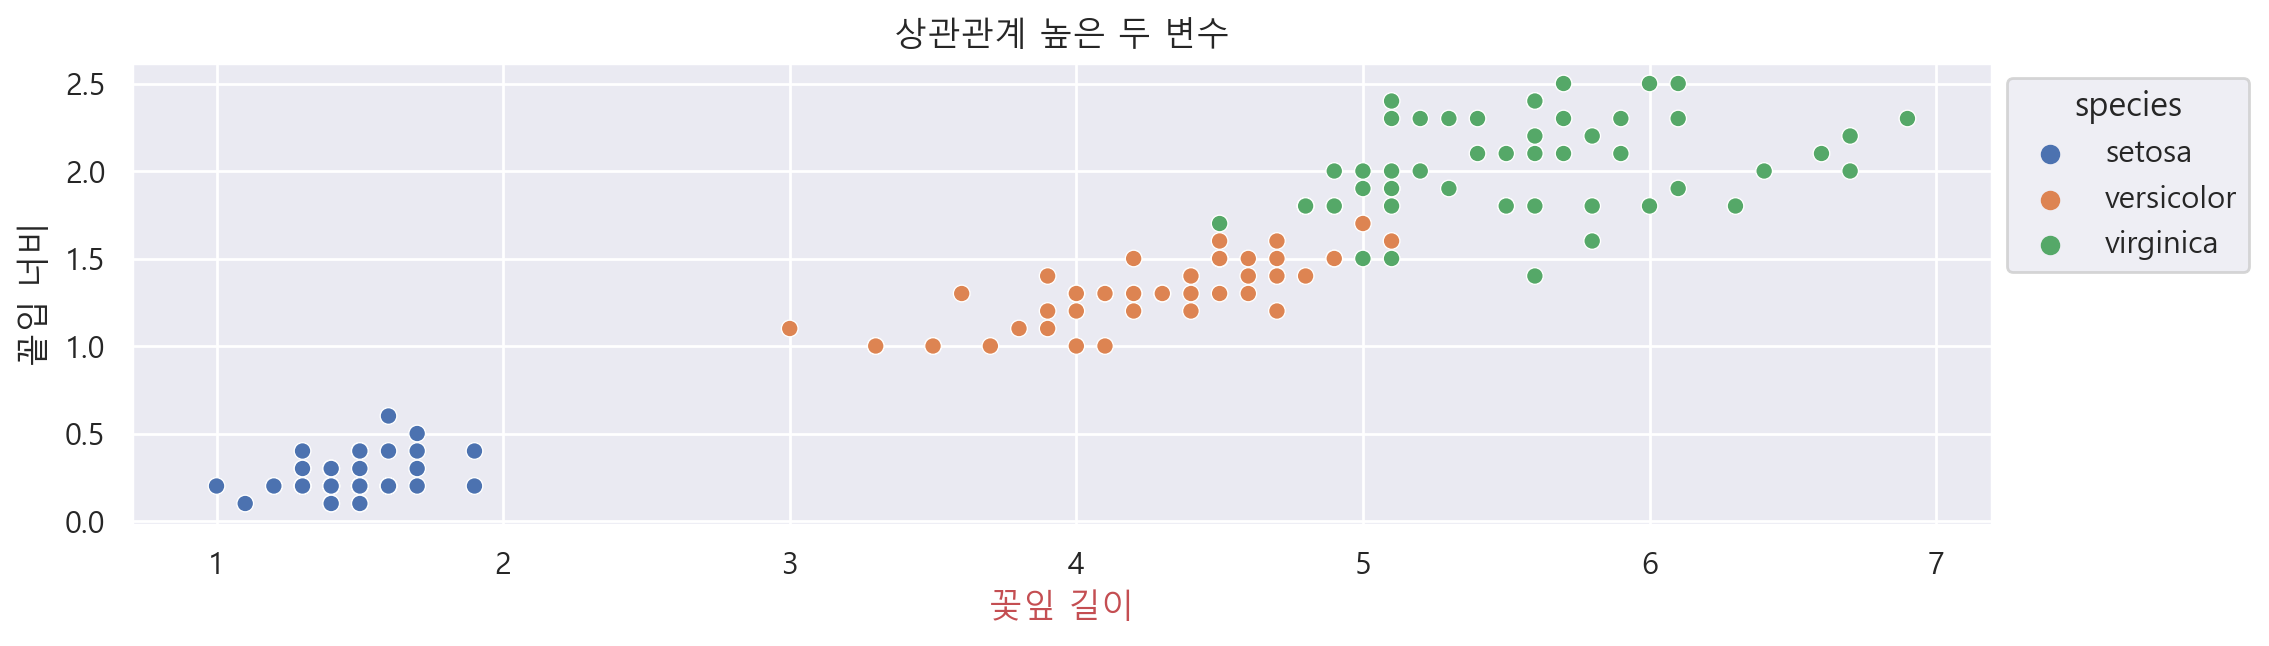

In [27]:
plt.figure(figsize=(12,3))
sns.set(style='darkgrid') # white, whitgrid, dark, darkgrid, ticks
plt.rc('font', family='Malgun Gothic') # 윈도우 폰트
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title='상관관계 높은 두 변수',
      ylabel='꽅입 너비')
ax.set_xlabel('꽃잎 길이', color='r')
plt.show()

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

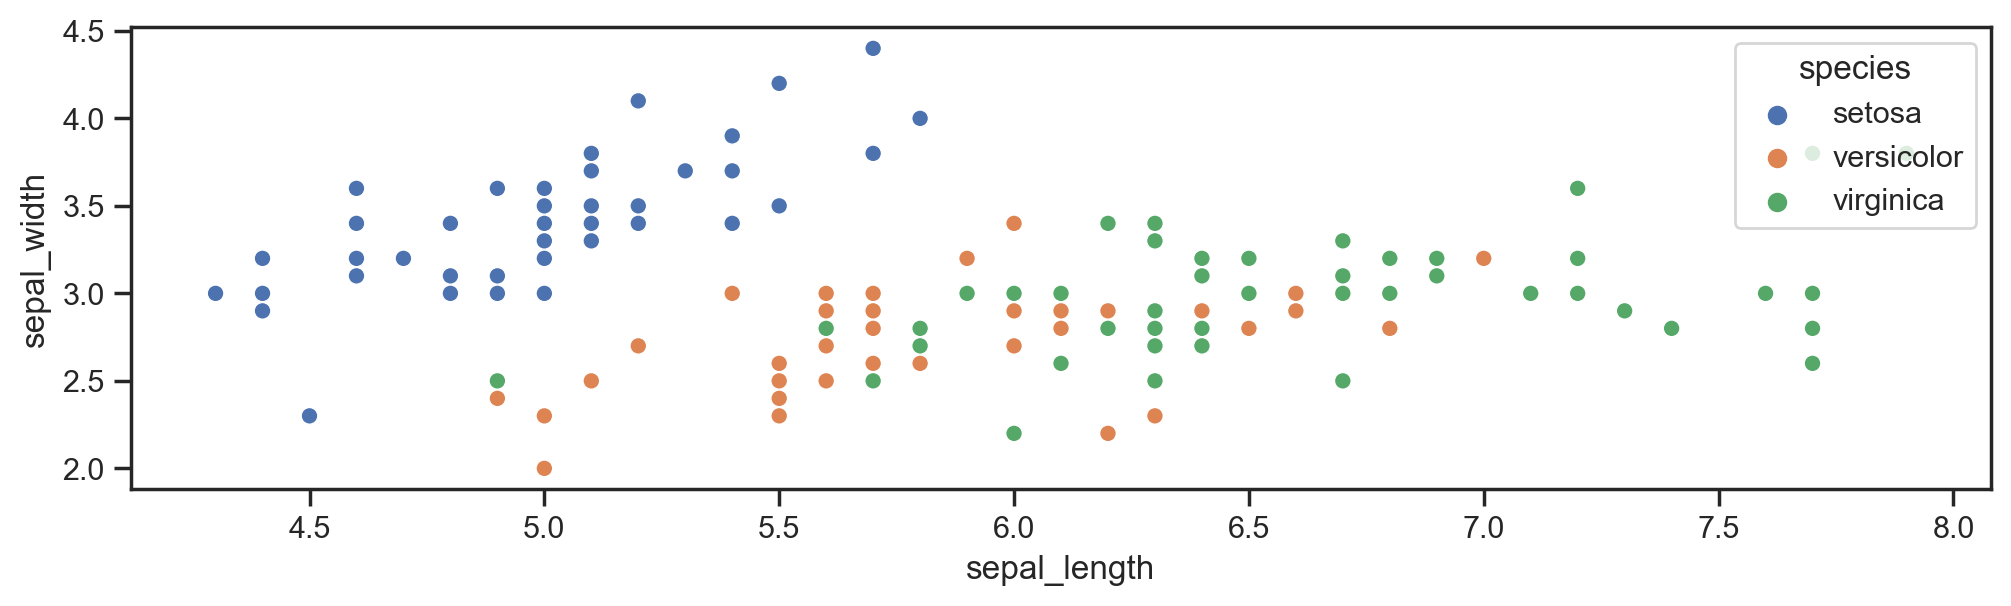

In [23]:
plt.figure(figsize=(12,3))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species')

### 2) 컨텍스트 지정 (비율)

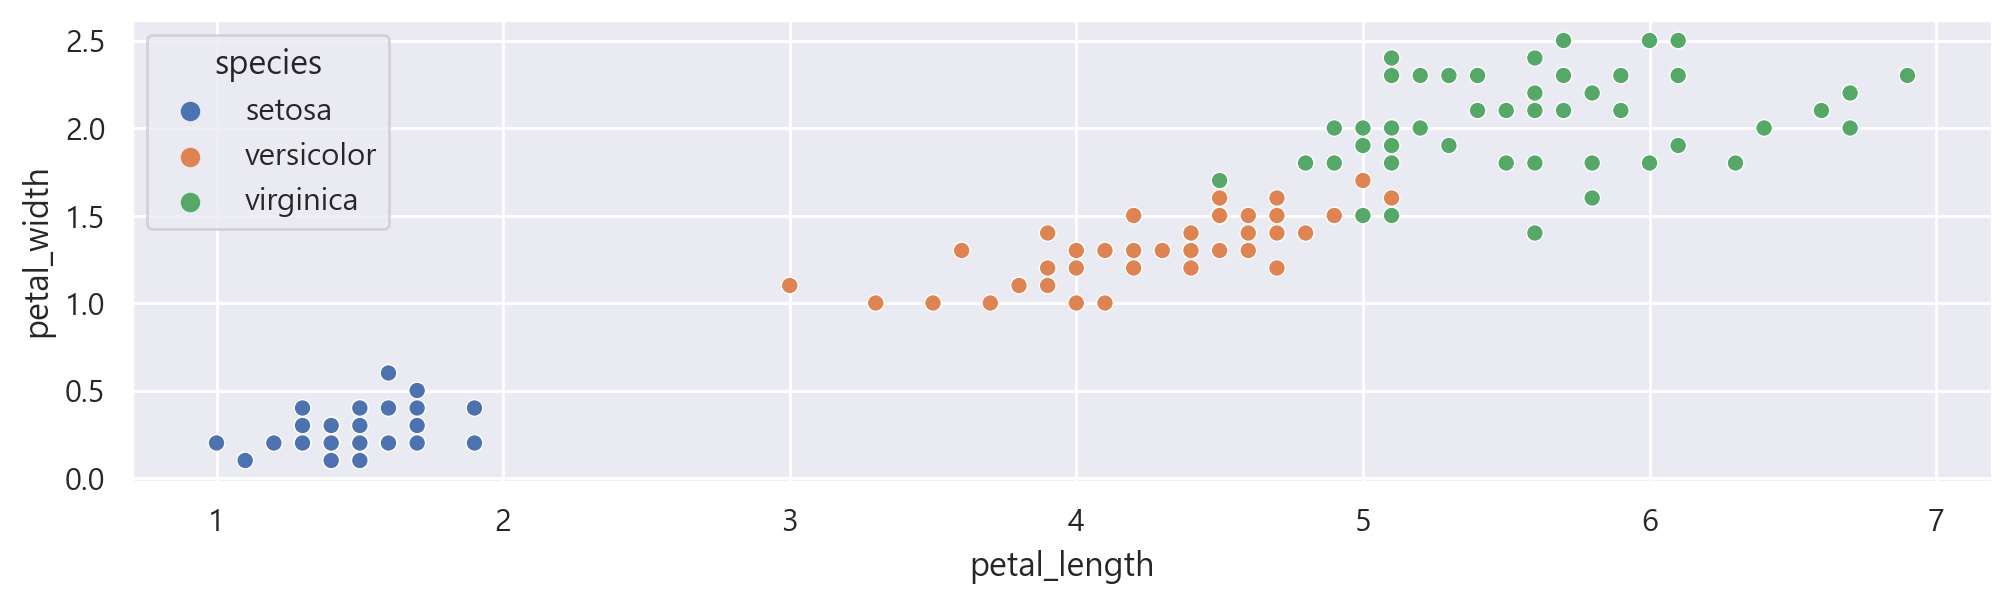

In [33]:
plt.figure(figsize=(12,3))
# sns.set(context='notebook') # notebook(1.0), paper(0.8), talk(1.3), poster(1.8)
sns.set_context('notebook')
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
plt.show()

### 3) 컬러 팔레트
- https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette
- https://matplotlib.org/tutorials/colors/colormaps.html
- https://seaborn.pydata.org/tutorial/color_palettes.html

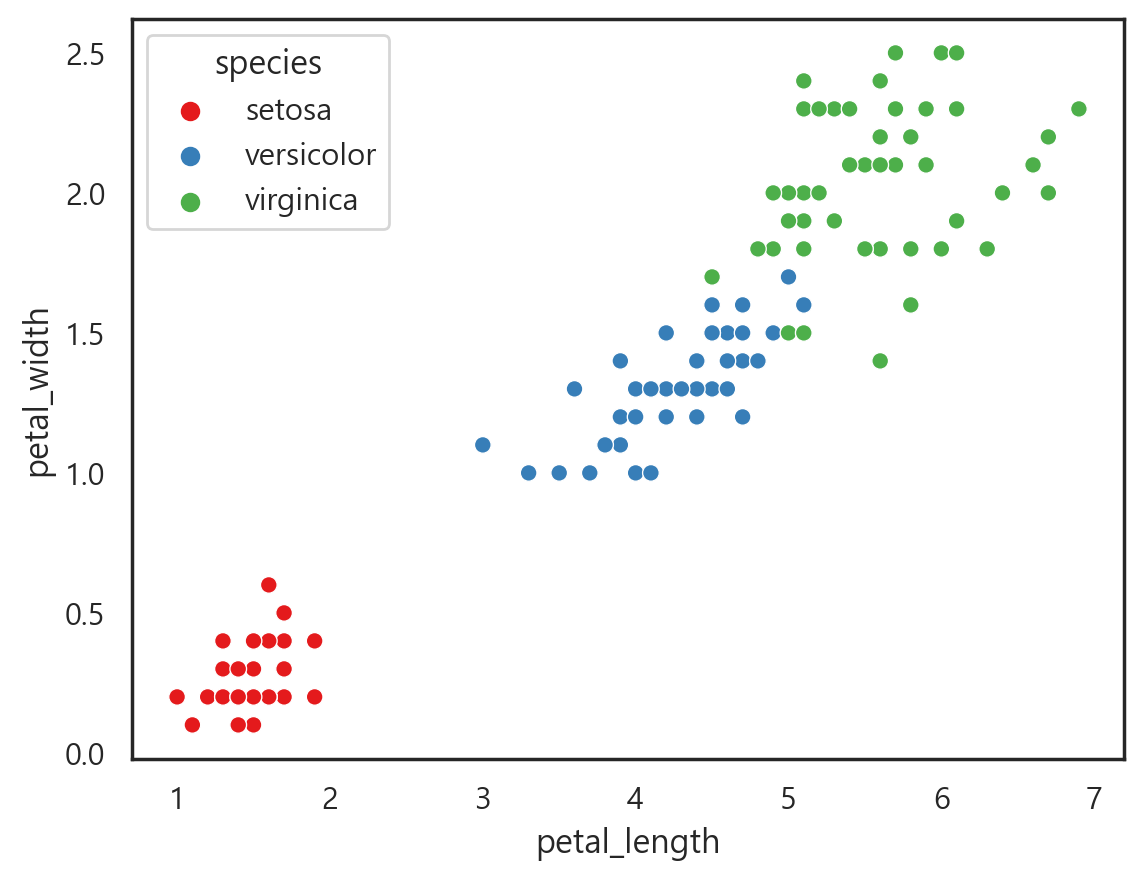

In [34]:
sns.set(palette='Pastel1', style='white', context='notebook') # 기본 미적 속성 설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
               hue='species', palette='Set1')
ax.set_title('붓꽃 데이터')
plt.show()

In [4]:
sns.set(palette='Dark2',
        style='whitegrid',
        context='notebook',
        rc={'figure.figsize':(10,3)}) # 기본 미적 속성 설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## 2.3 seaborn함수로 그래프 그리기
### 1) 관계형 그래프
    - x축이 수치형 데이터
    ex) scatterplot, lineplot => relplot (서브플롯)

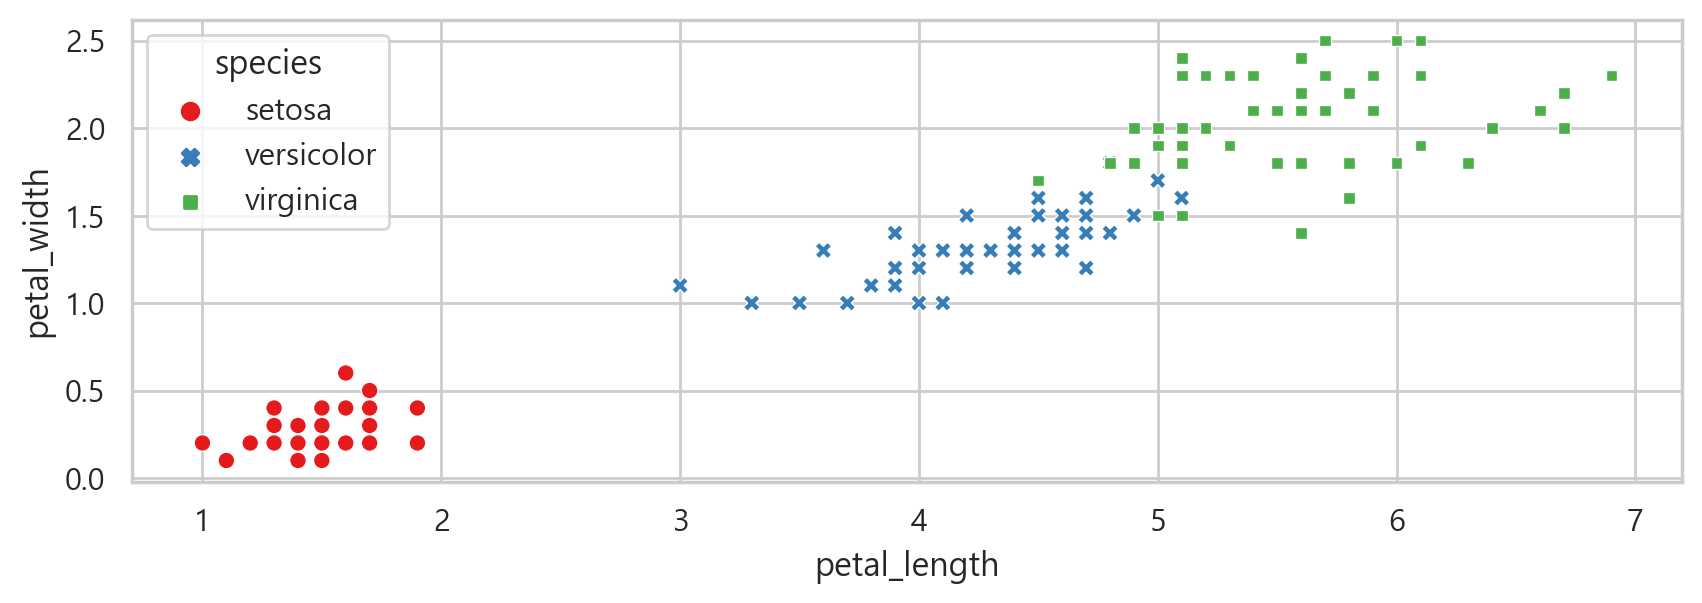

In [38]:
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', 
                palette='Set1', style='species')
    # species별로 색상과 스타일이 다른 scatterplot
plt.show()

<Axes: xlabel='petal_length', ylabel='petal_width'>

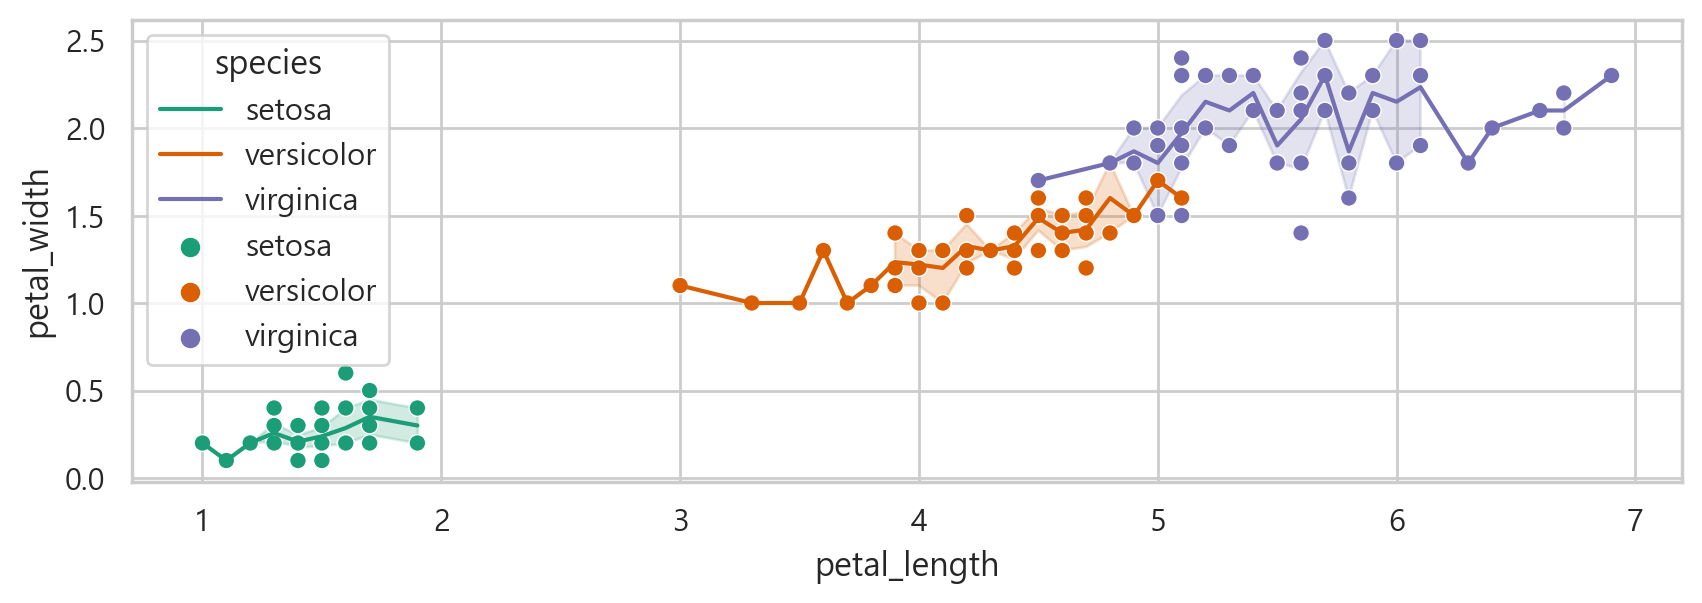

In [41]:
# lineplot의 음영 : 95% 신뢰구간
# scatter와 line을 겹쳐서
sns.lineplot(data=iris, x='petal_length', y='petal_width', hue='species')
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
plt.show()

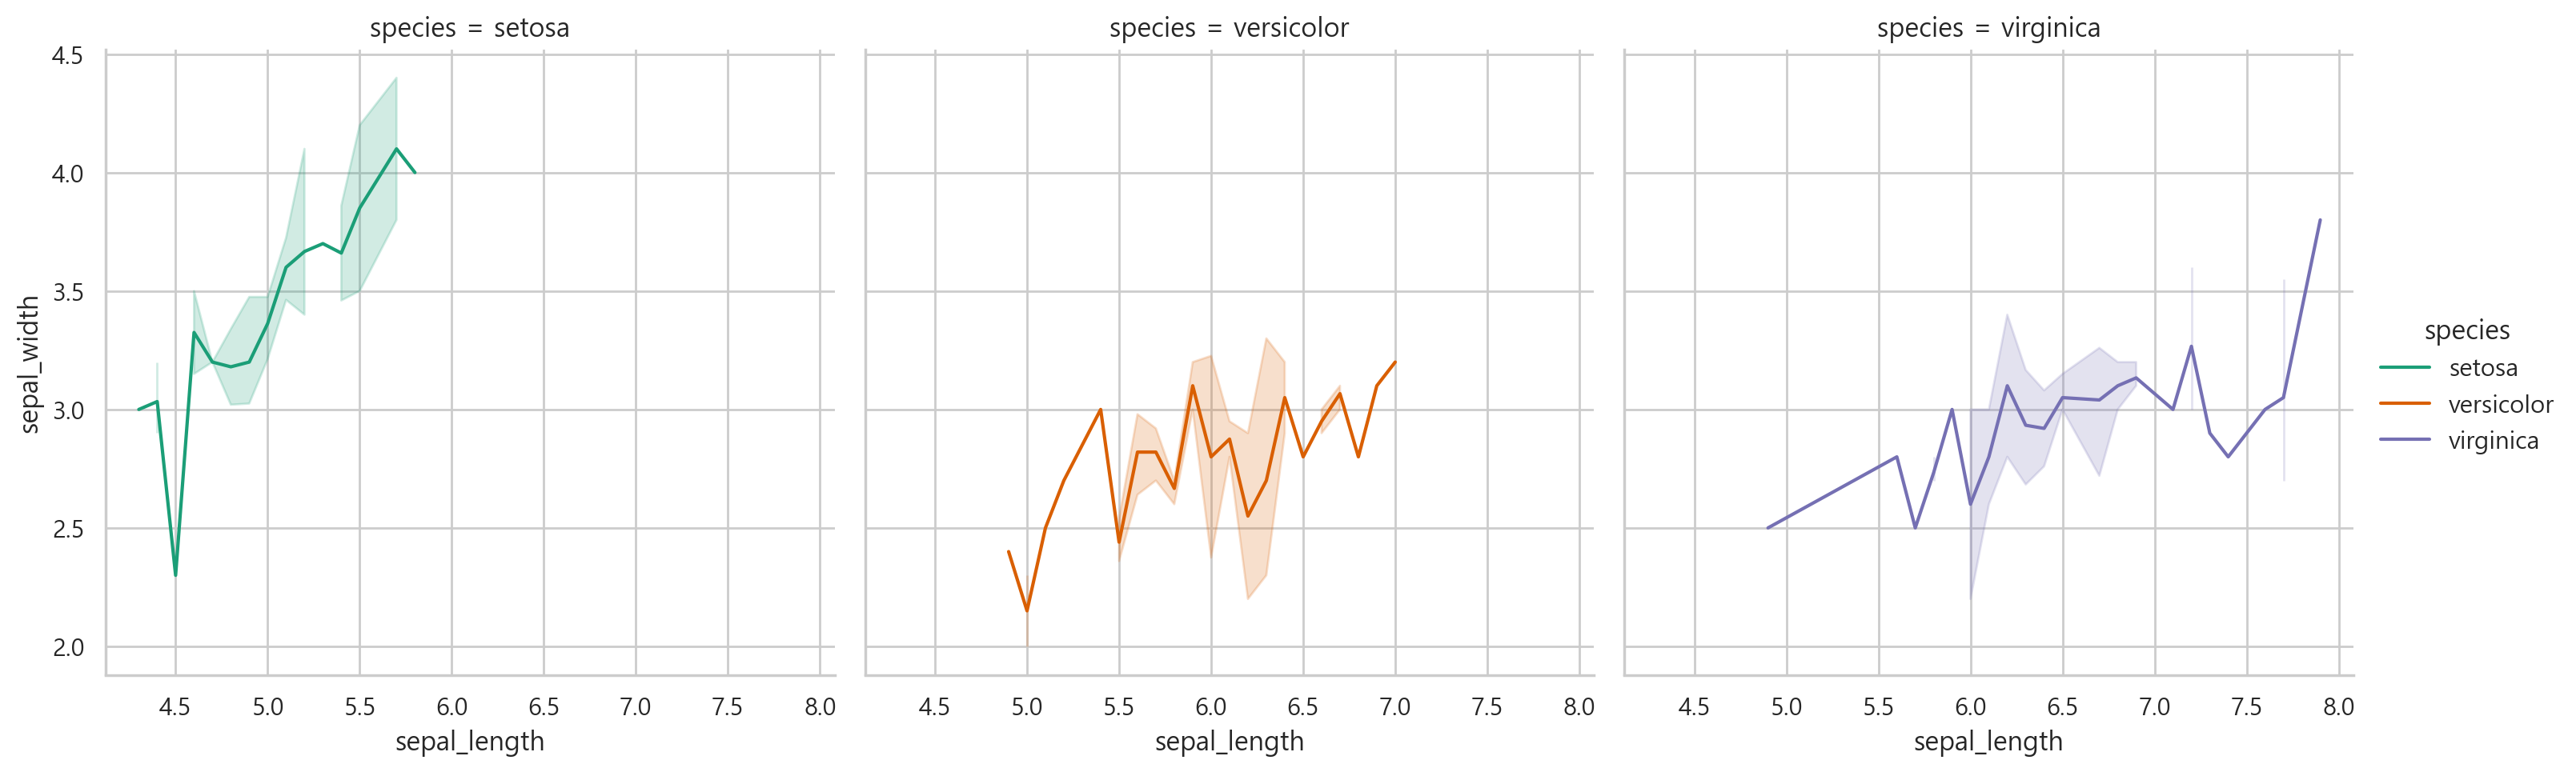

In [54]:
# 종별 lineplot을 서브플롯으로
sns.relplot(data=iris, x='sepal_length', y='sepal_width',
            hue='species',
            kind='line', # kind='scatter'
            col='species',
            #col_wrap=2   # 한줄에 표현될 서브플롯 수
           )

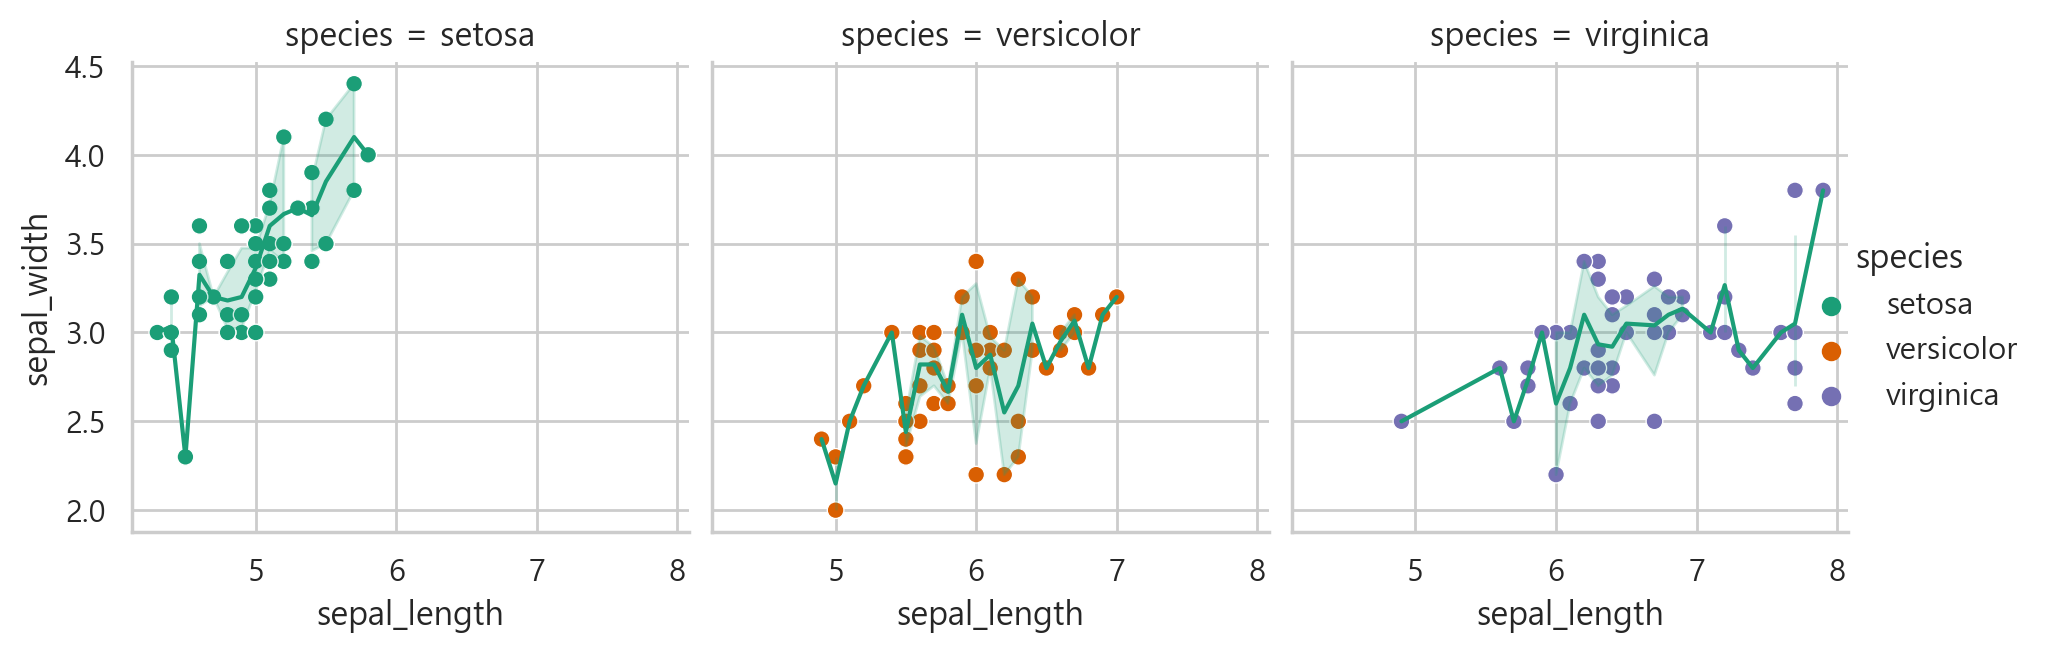

In [55]:
# line과 scatter를 종별 서브플롯으로 겹쳐서
g = sns.relplot(data=iris, x='sepal_length', y='sepal_width',
            hue='species',
            #kind='line', # kind='scatter'
            col='species',
            #col_wrap=2   # 한줄에 표현될 서브플롯 수
           )
# g그래프에 line플롯을 추가
g.map_dataframe(sns.lineplot, x='sepal_length', y='sepal_width')
# 크기 조정 : 서브플롯함수에서는 내부적으로 figure 객체를 새로 만들기 때문에 figsize 무시
g.fig.set_size_inches(10,3)


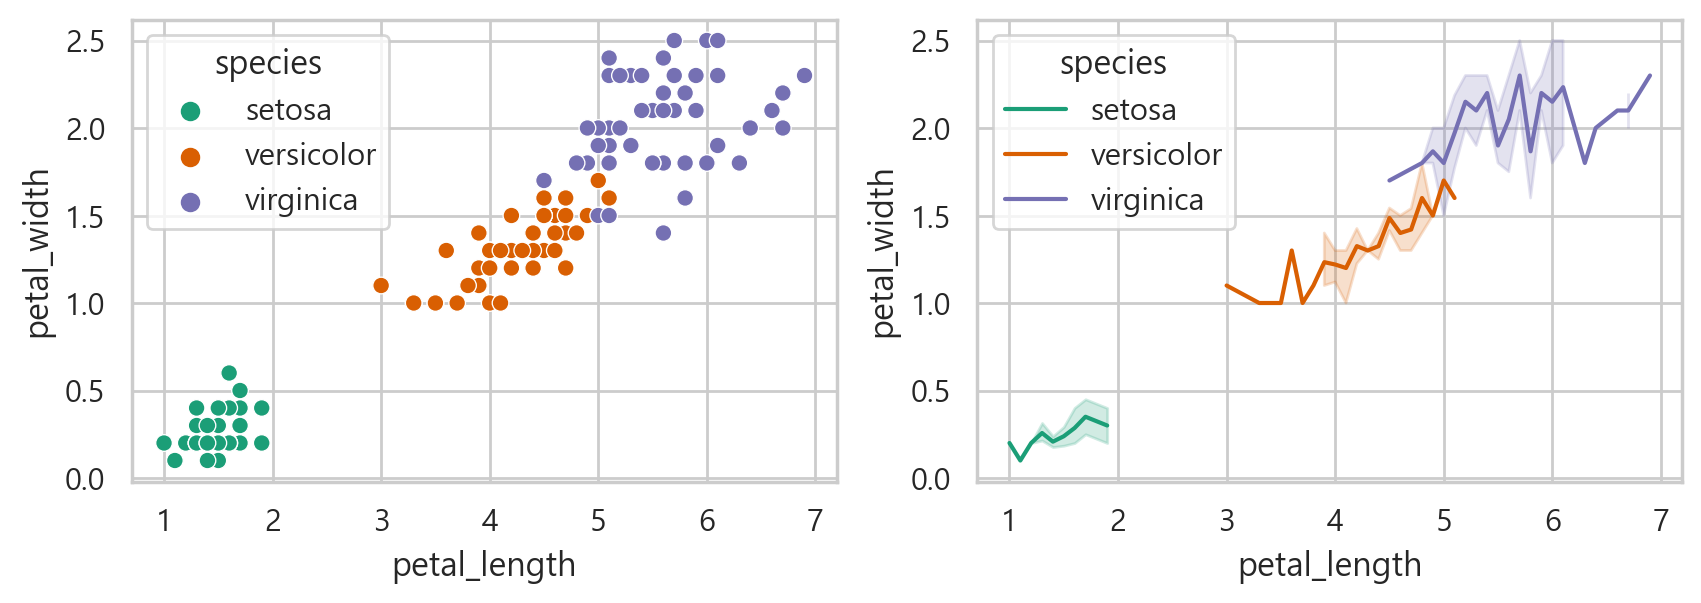

In [62]:
# ax[0]에는 scatter, ax[1] line plot
fig, ax = plt.subplots(1, ncols=2)
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species',
                ax=ax[0])
sns.lineplot(data=iris, x='petal_length', y='petal_width',
                hue='species',
                ax=ax[1])
plt.show()

### 2) 범주형 그래프
    - x축이 범주형 데이터
    (ex) stripplot (무작위 흩뿌림), swarmplot(겹치지 않는 산점도)
         barplot, barhplot(y의 평균으로 막대 그래프), pointplot(y의 평균으로 line)
         countplot(count는 x의 빈도수가 높이)
         boxplot, violinplot, boxenplot
         => catplot(서브플롯)

<Axes: xlabel='species', ylabel='petal_width'>

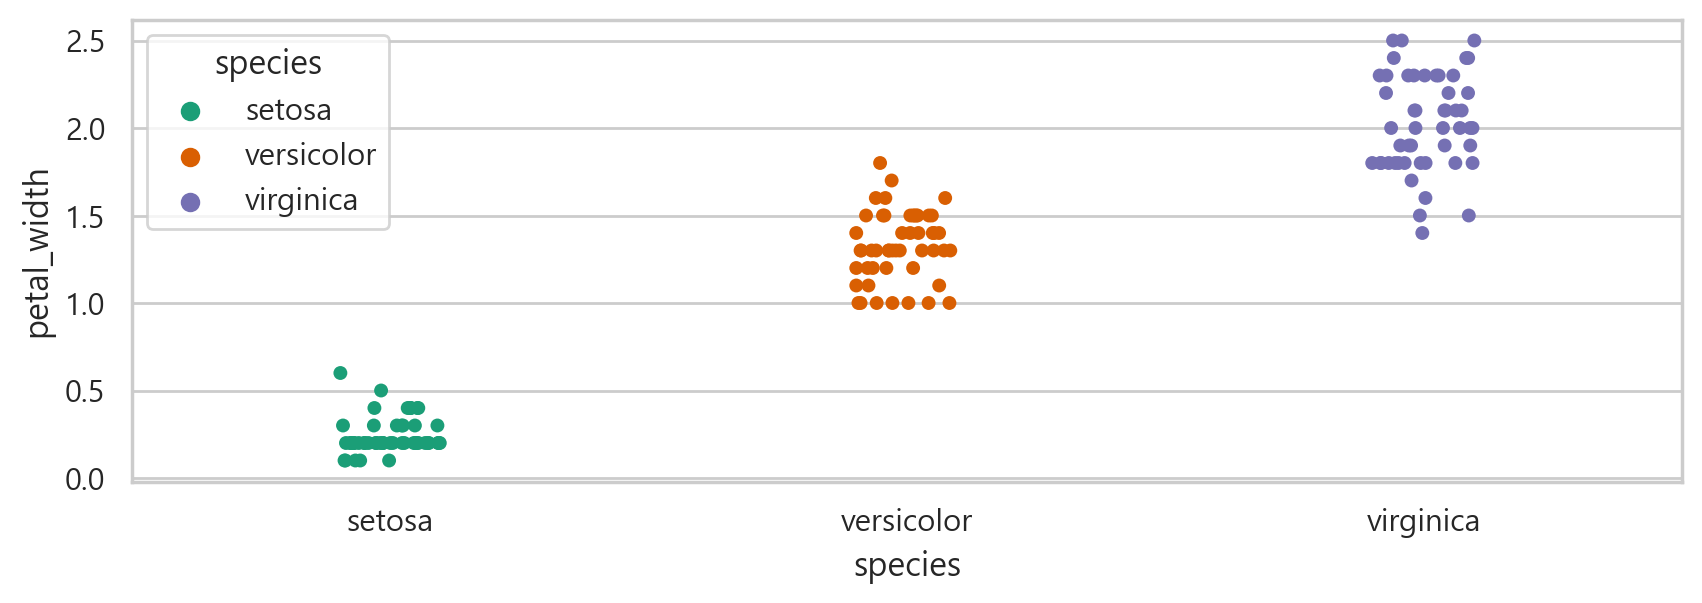

In [64]:
# x툭이 범주형일 때의 산점도
sns.stripplot(data=iris, x='species', y='petal_width', hue='species')

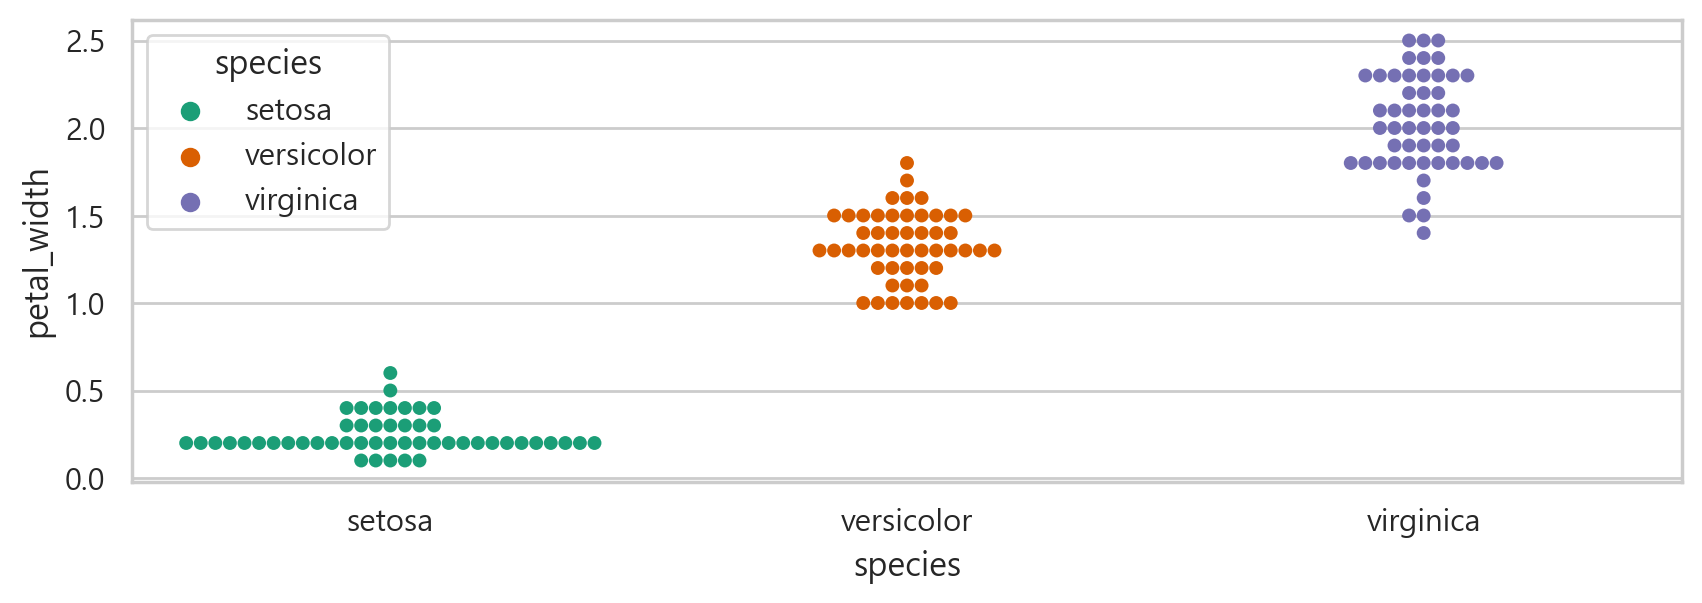

In [63]:
# x축이 범주형일 때 산점도 (분포 포함)
sns.swarmplot(data=iris, x='species', y='petal_width', hue='species')
plt.show()

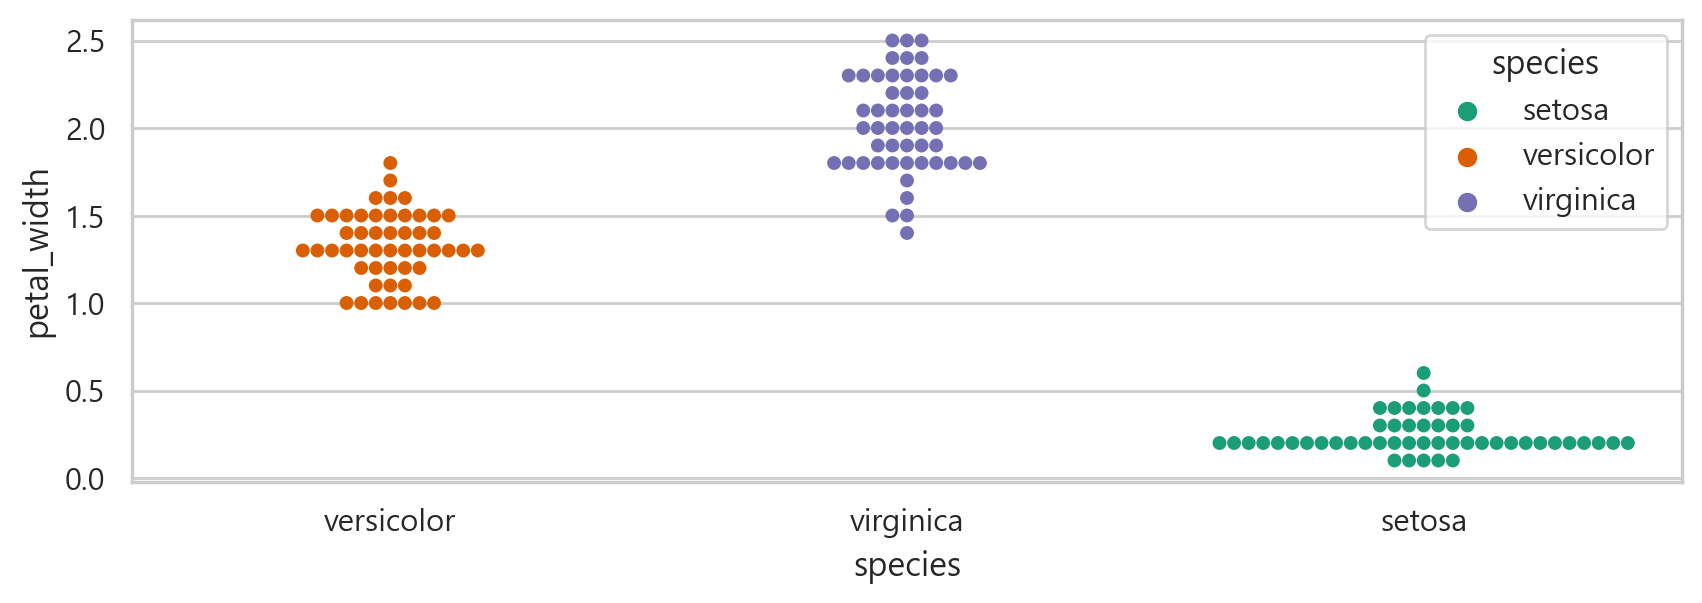

In [28]:
# 범주형 그래프의 x축을 지정하지 않으면
sns.swarmplot(data=iris,
             x='species',
             y='petal_width',
             hue='species',
             order=['versicolor', 'virginica', 'setosa']
             )
plt.show()

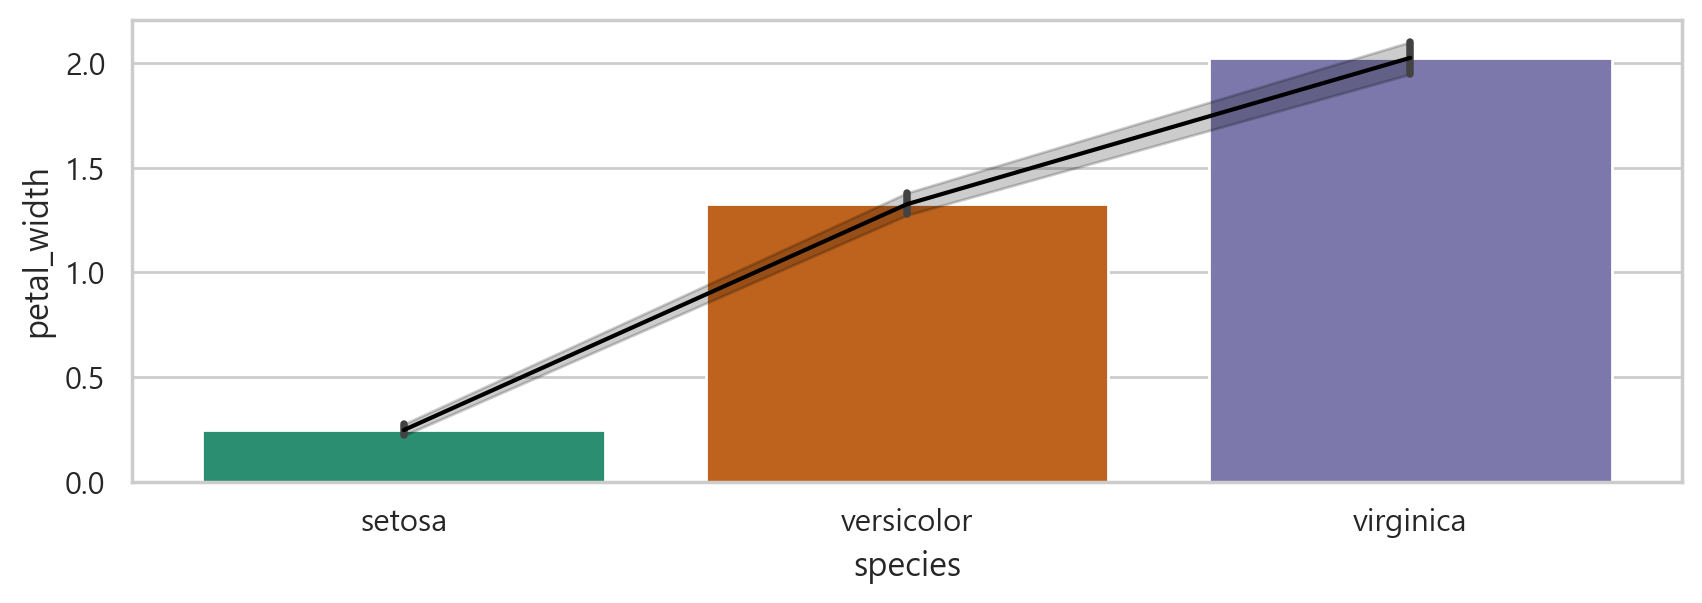

In [6]:
# baplot, barhplot, pointplot : 각 범주별 평균값(y)과 그에 대한 신뢰구간
# 신뢰구간 제외 : errorbar=None
sns.barplot(data=iris,x='species',y='petal_width',
           #errorbar=None
           )
sns.lineplot(data=iris, x='species',y='petal_width', color='k' )
plt.show()

<Axes: xlabel='species', ylabel='petal_width'>

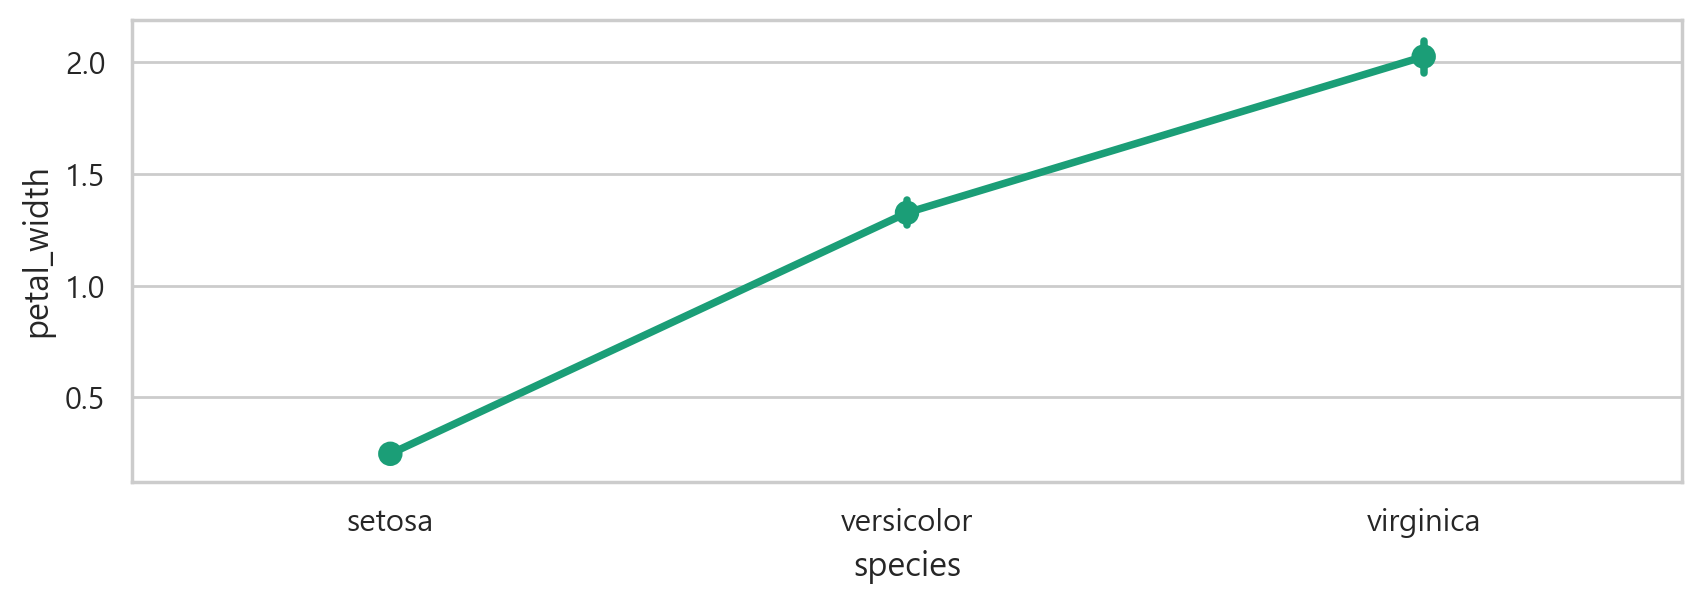

In [10]:
sns.pointplot(data=iris, x='species',y='petal_width')

In [13]:
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [15]:
titanic.dtypes.head(3)

survived     int64
pclass       int64
sex         object
dtype: object

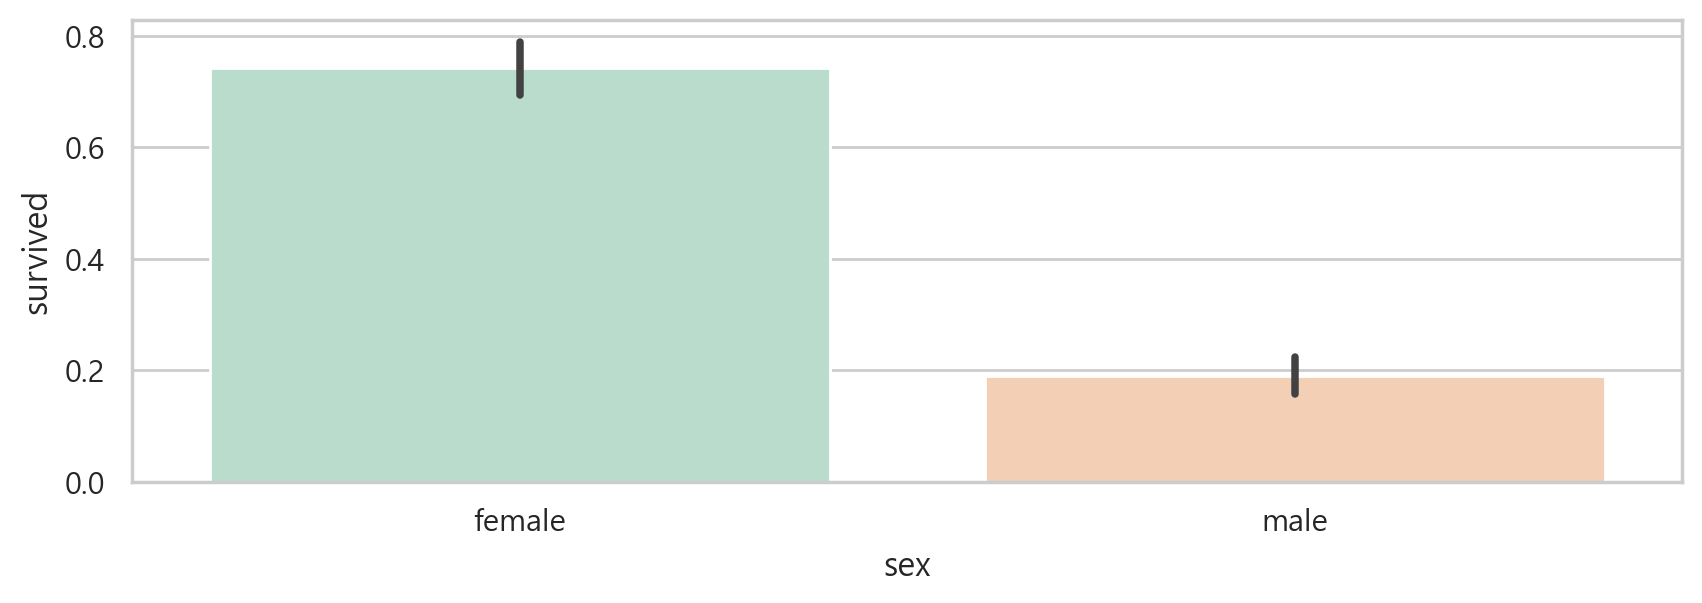

In [21]:
# 성별 생존율을 막대그래프
sns.barplot(data=titanic, 
           x='sex',
           y='survived',
           order=['female','male'],
           palette='Pastel2')
plt.show()

In [29]:
titanic.sex.value_counts()

male      577
female    314
Name: sex, dtype: int64

In [31]:
# 남자중 비생존자
len(titanic[(titanic.sex=='male') & (titanic.survived==0)])

468

In [32]:
# 남자중 생존자
len(titanic[(titanic.sex=='male') & (titanic.survived==1)])

109

In [33]:
# 여자중 비생존자
len(titanic[(titanic.sex=='female') & (titanic.survived==0)])

81

In [34]:
# 여자중 생존자
len(titanic[(titanic.sex=='female') & (titanic.survived==1)])

233

In [35]:
titanic.sample(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
642,0,3,female,2.0,3,2,27.9000,S,Third,child,False,NaN,Southampton,no,False
843,0,3,male,34.5,0,0,6.4375,C,Third,man,True,NaN,Cherbourg,no,True


In [36]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

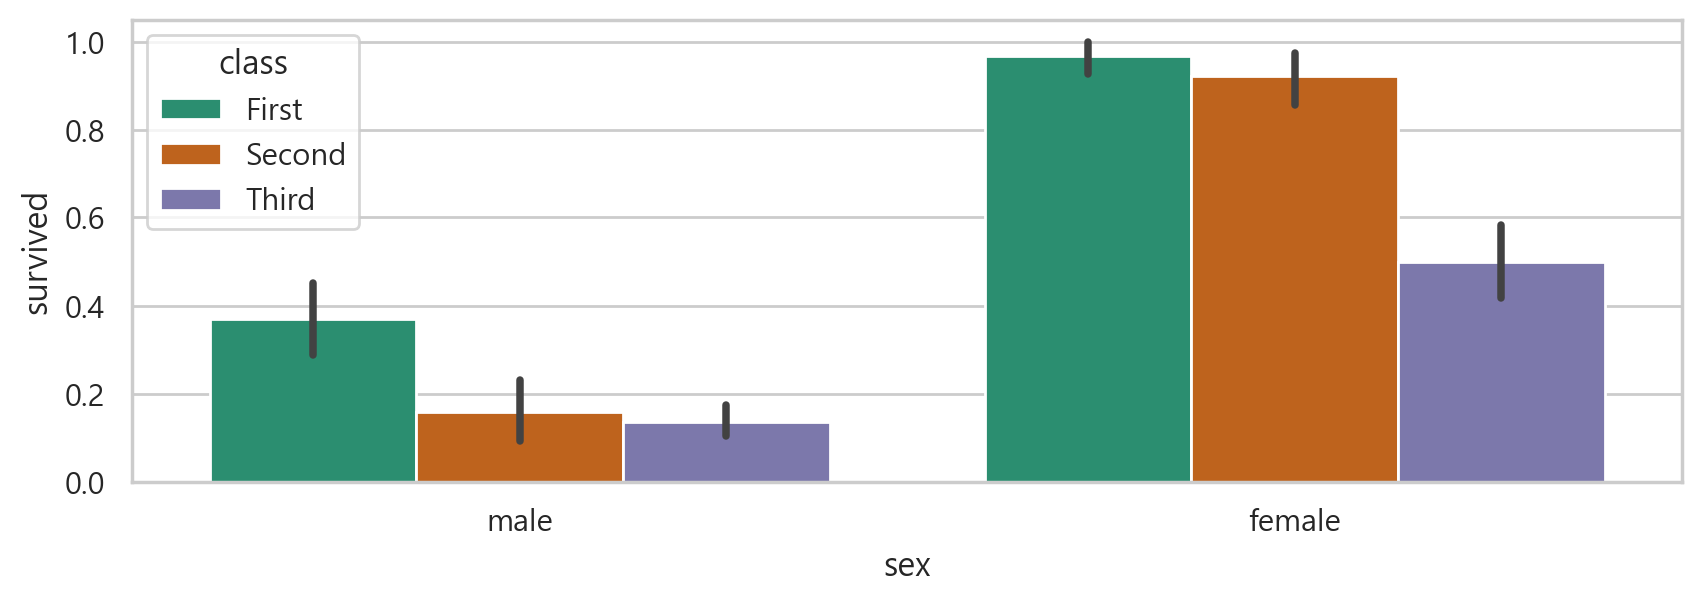

In [50]:
# 성별 생존율 hue='class'
sns.barplot(data=titanic, x='sex', y='survived', hue = 'class')
plt.show()

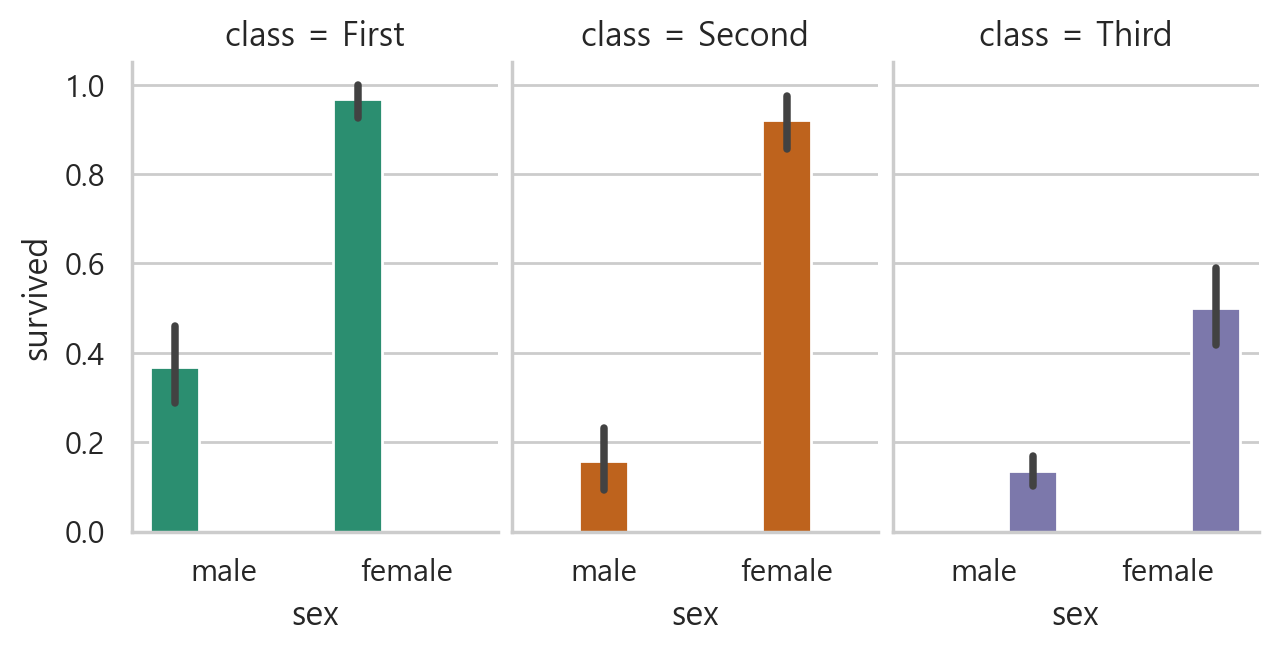

In [52]:
# class별로 성별생존률을 서브플롯(막대그래프)
g=sns.catplot(data=titanic,
           x='sex',
           y='survived',
           hue='class',
           kind='bar', # 기본값은 stripplot
           col='class',
           #col_wrap=2, # 한행에 그려질 서브플롯 갯수, 기본값은 n
           )
g.fig.set_size_inches(6,3)

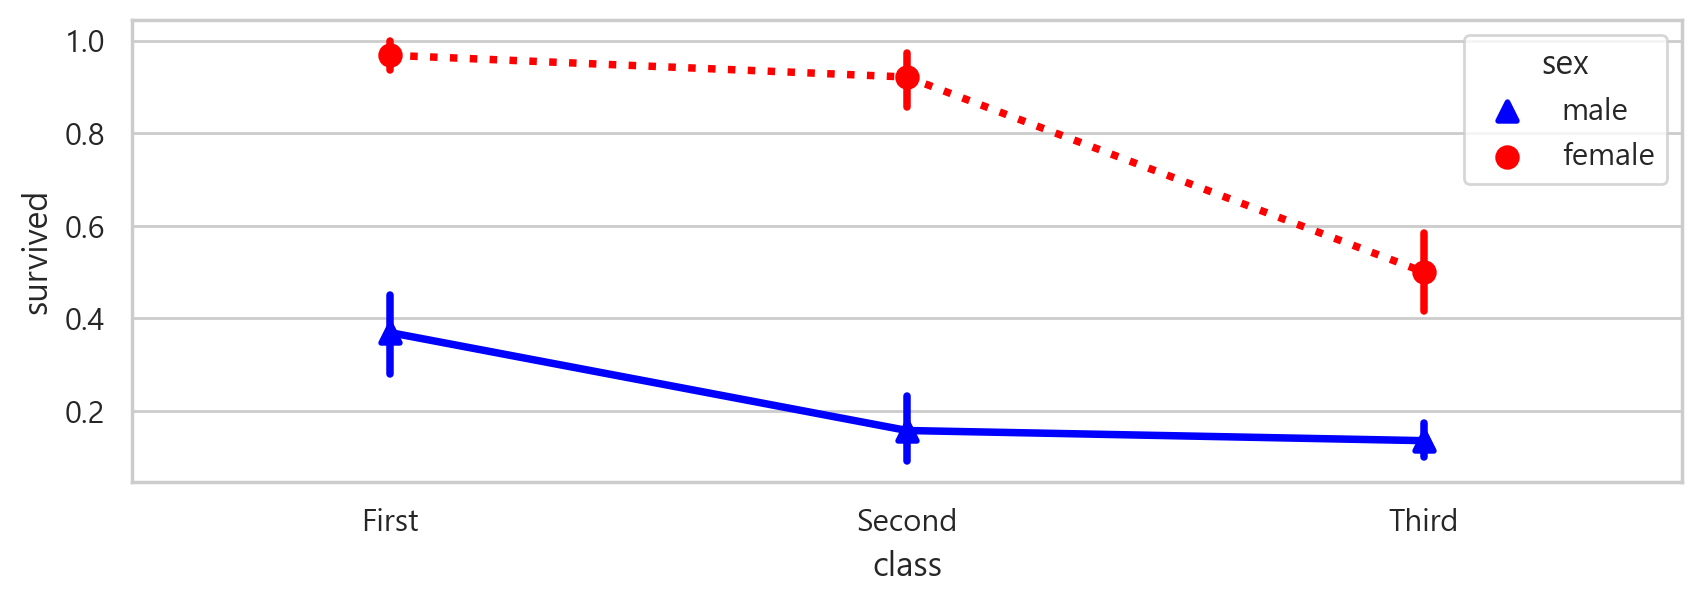

In [53]:
# 성별 생존율 hue='class'
sns.pointplot(data=titanic, x='class', y='survived', 
                hue = 'sex',
                markers=['^','o'],
                linestyles=['-',':'],
                palette={'male':'b', 'female':'r'}
             )
plt.show()

In [55]:
t_len = len(titanic)
nalen = titanic.deck.isna().sum()
d_len = t_len - nalen
print('deck 전체 데이타 갯수 : {}, 결측치 갯수 : {}, 데이터 갯수 : {}'.format(t_len,nalen,d_len))

deck 전체 데이타 갯수 : 891, 결측치 갯수 : 688, 데이터 갯수 : 203


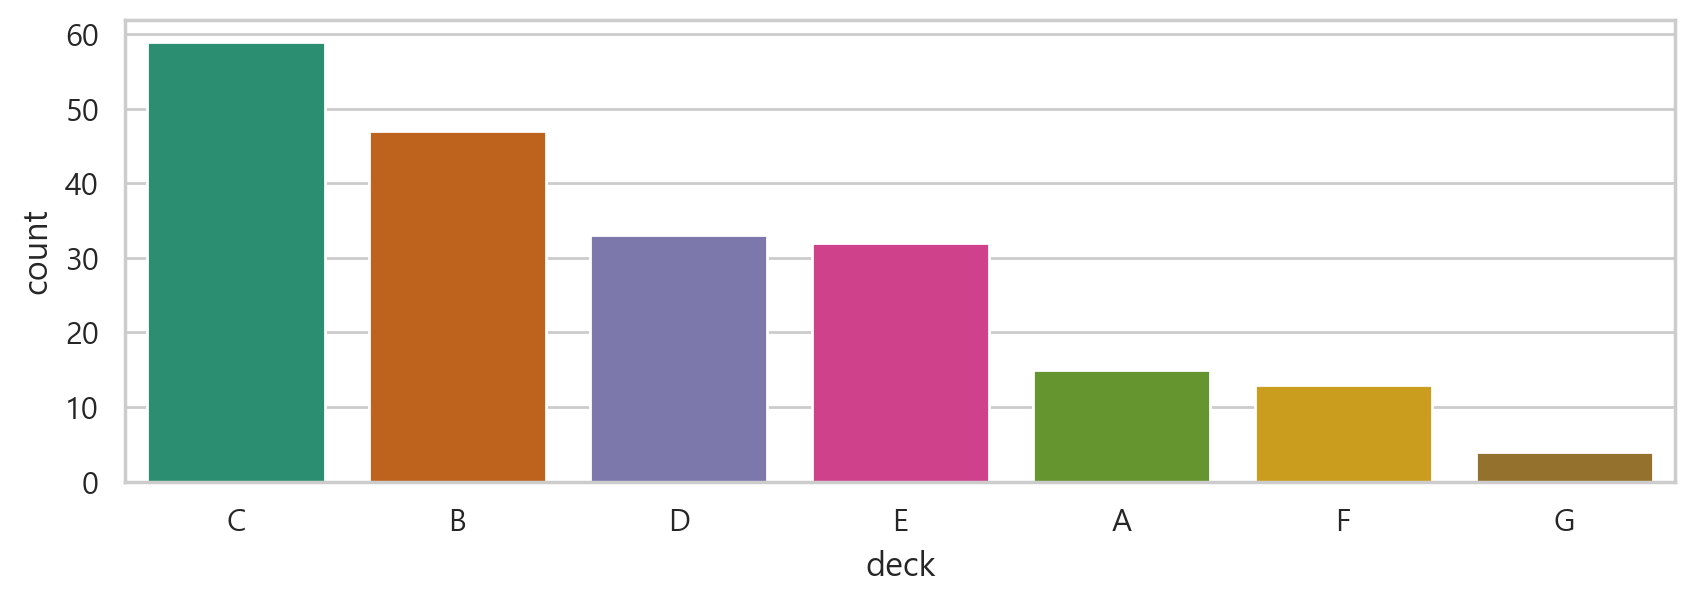

In [64]:
# deck별 갯수를 막대그래프(countplot)
sns.countplot(data=titanic,
             x='deck',
             #order=['C','B','D','E','A','F','G']
             order=dec_cnt.index
             )
plt.show()

In [63]:
dec_cnt = titanic.deck.value_counts() # 범주별 데이터 갯수 (정렬포함)
dec_cnt # deckcnt.index가 count가 큰순

C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: deck, dtype: int64

<Axes: xlabel='sex', ylabel='age'>

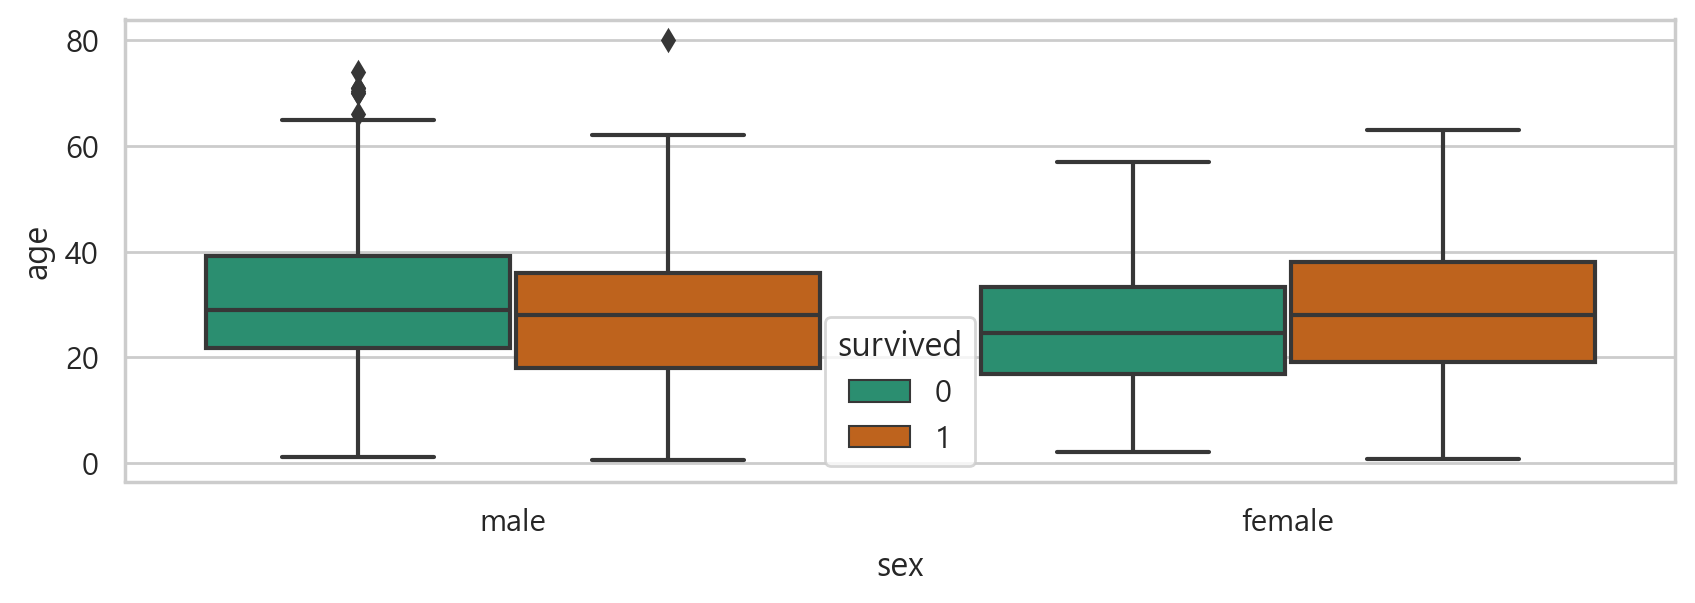

In [66]:
# boxplot
sns.boxplot(data=titanic, x='sex', y='age', hue='survived')

<Axes: xlabel='sex', ylabel='age'>

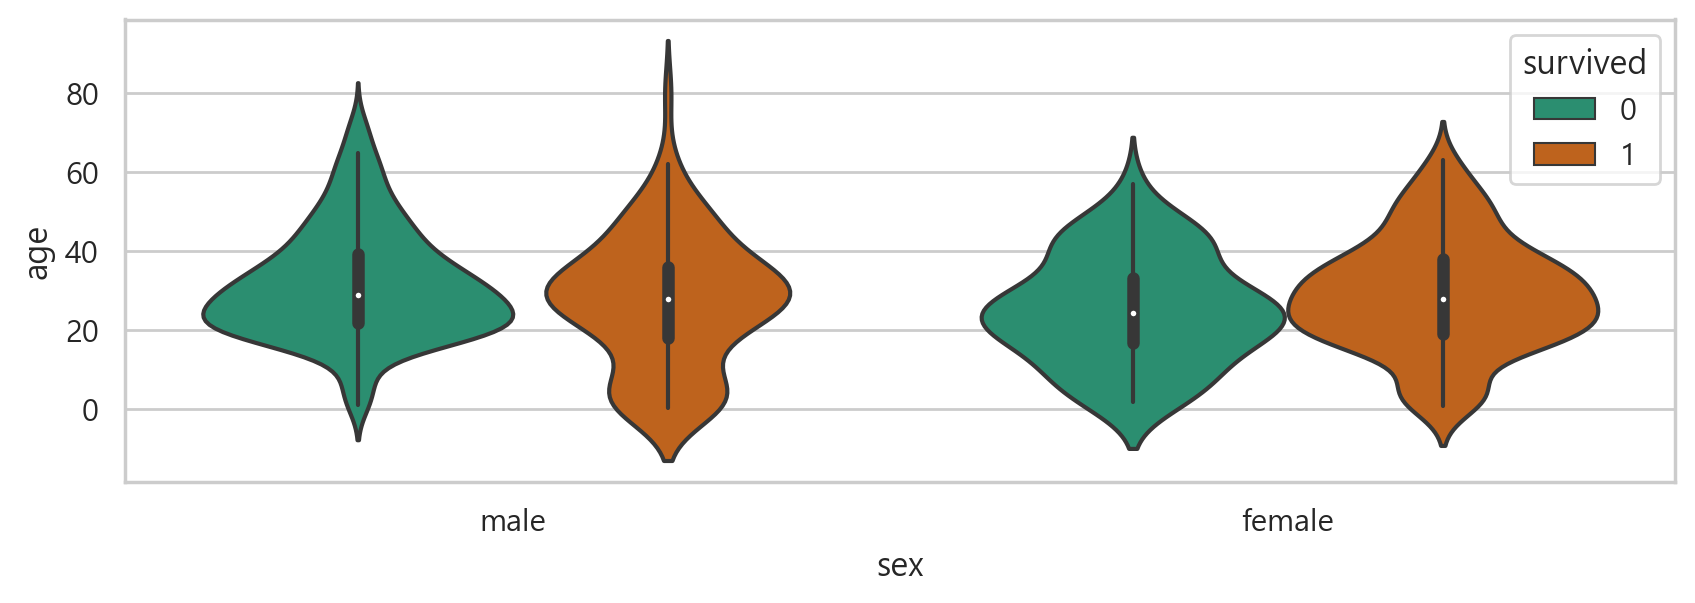

In [67]:
# violinplot
sns.violinplot(data=titanic, x='sex', y='age', hue='survived')

<Axes: xlabel='age', ylabel='sex'>

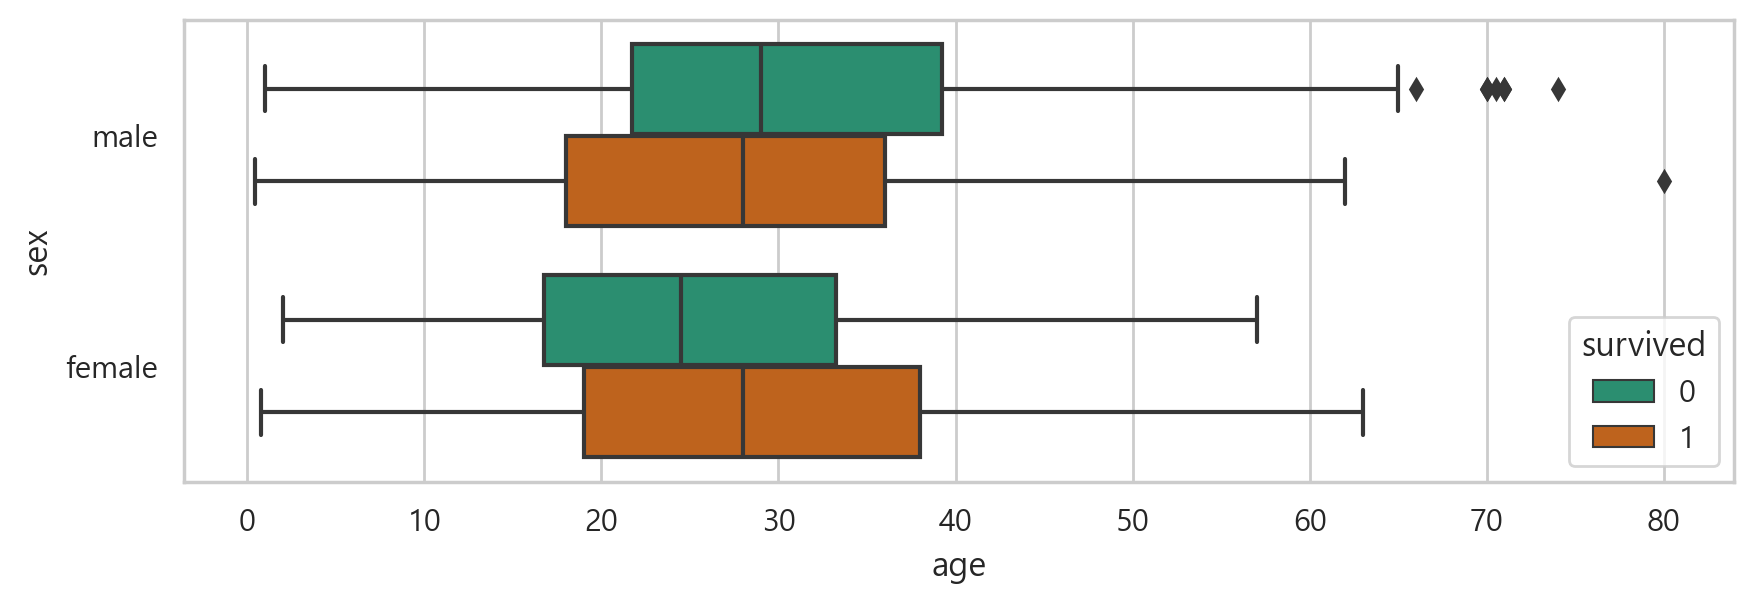

In [69]:
# boxhplot
sns.boxplot(data=titanic, y='sex', x='age', hue='survived')

<Axes: xlabel='age', ylabel='sex'>

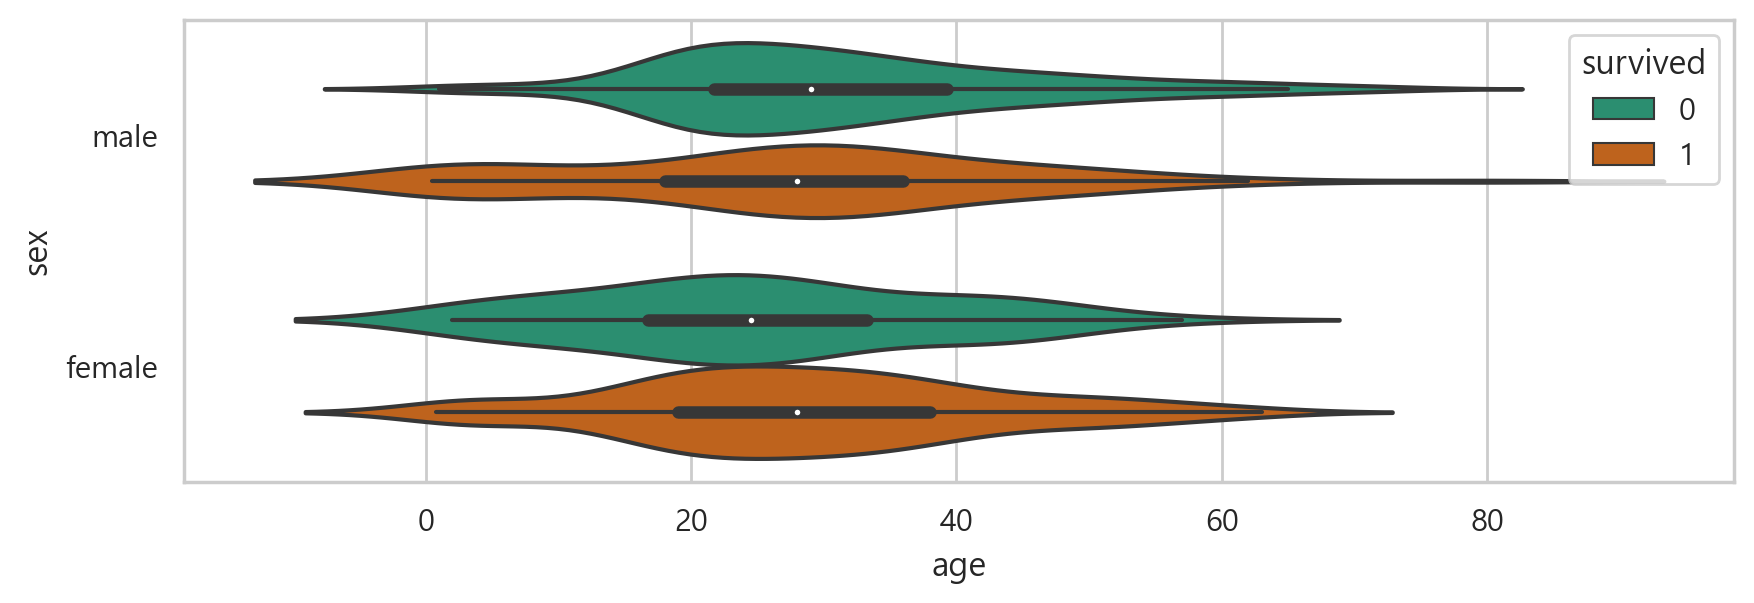

In [70]:
# violinplot
sns.violinplot(data=titanic, y='sex', x='age', hue='survived')

<Axes: xlabel='sex', ylabel='age'>

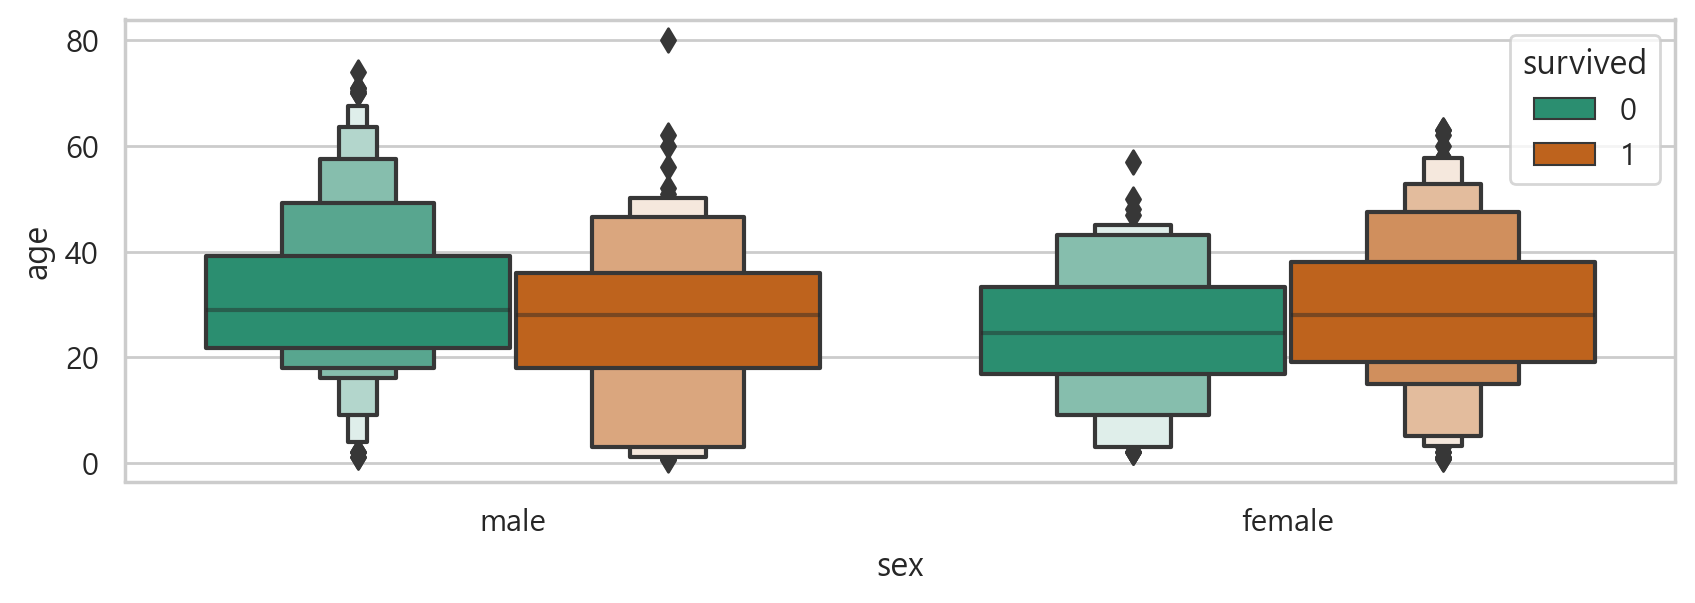

In [71]:
# boxenplot : box플롯 + 분포
sns.boxenplot(data=titanic, x='sex', y='age', hue='survived')

### 3) 쌍관계 그래프
- pairplot : 데이타프레임에 포함된 모든 수치형 변수 쌍에 대해 산점도(scatter)와 히스토그램

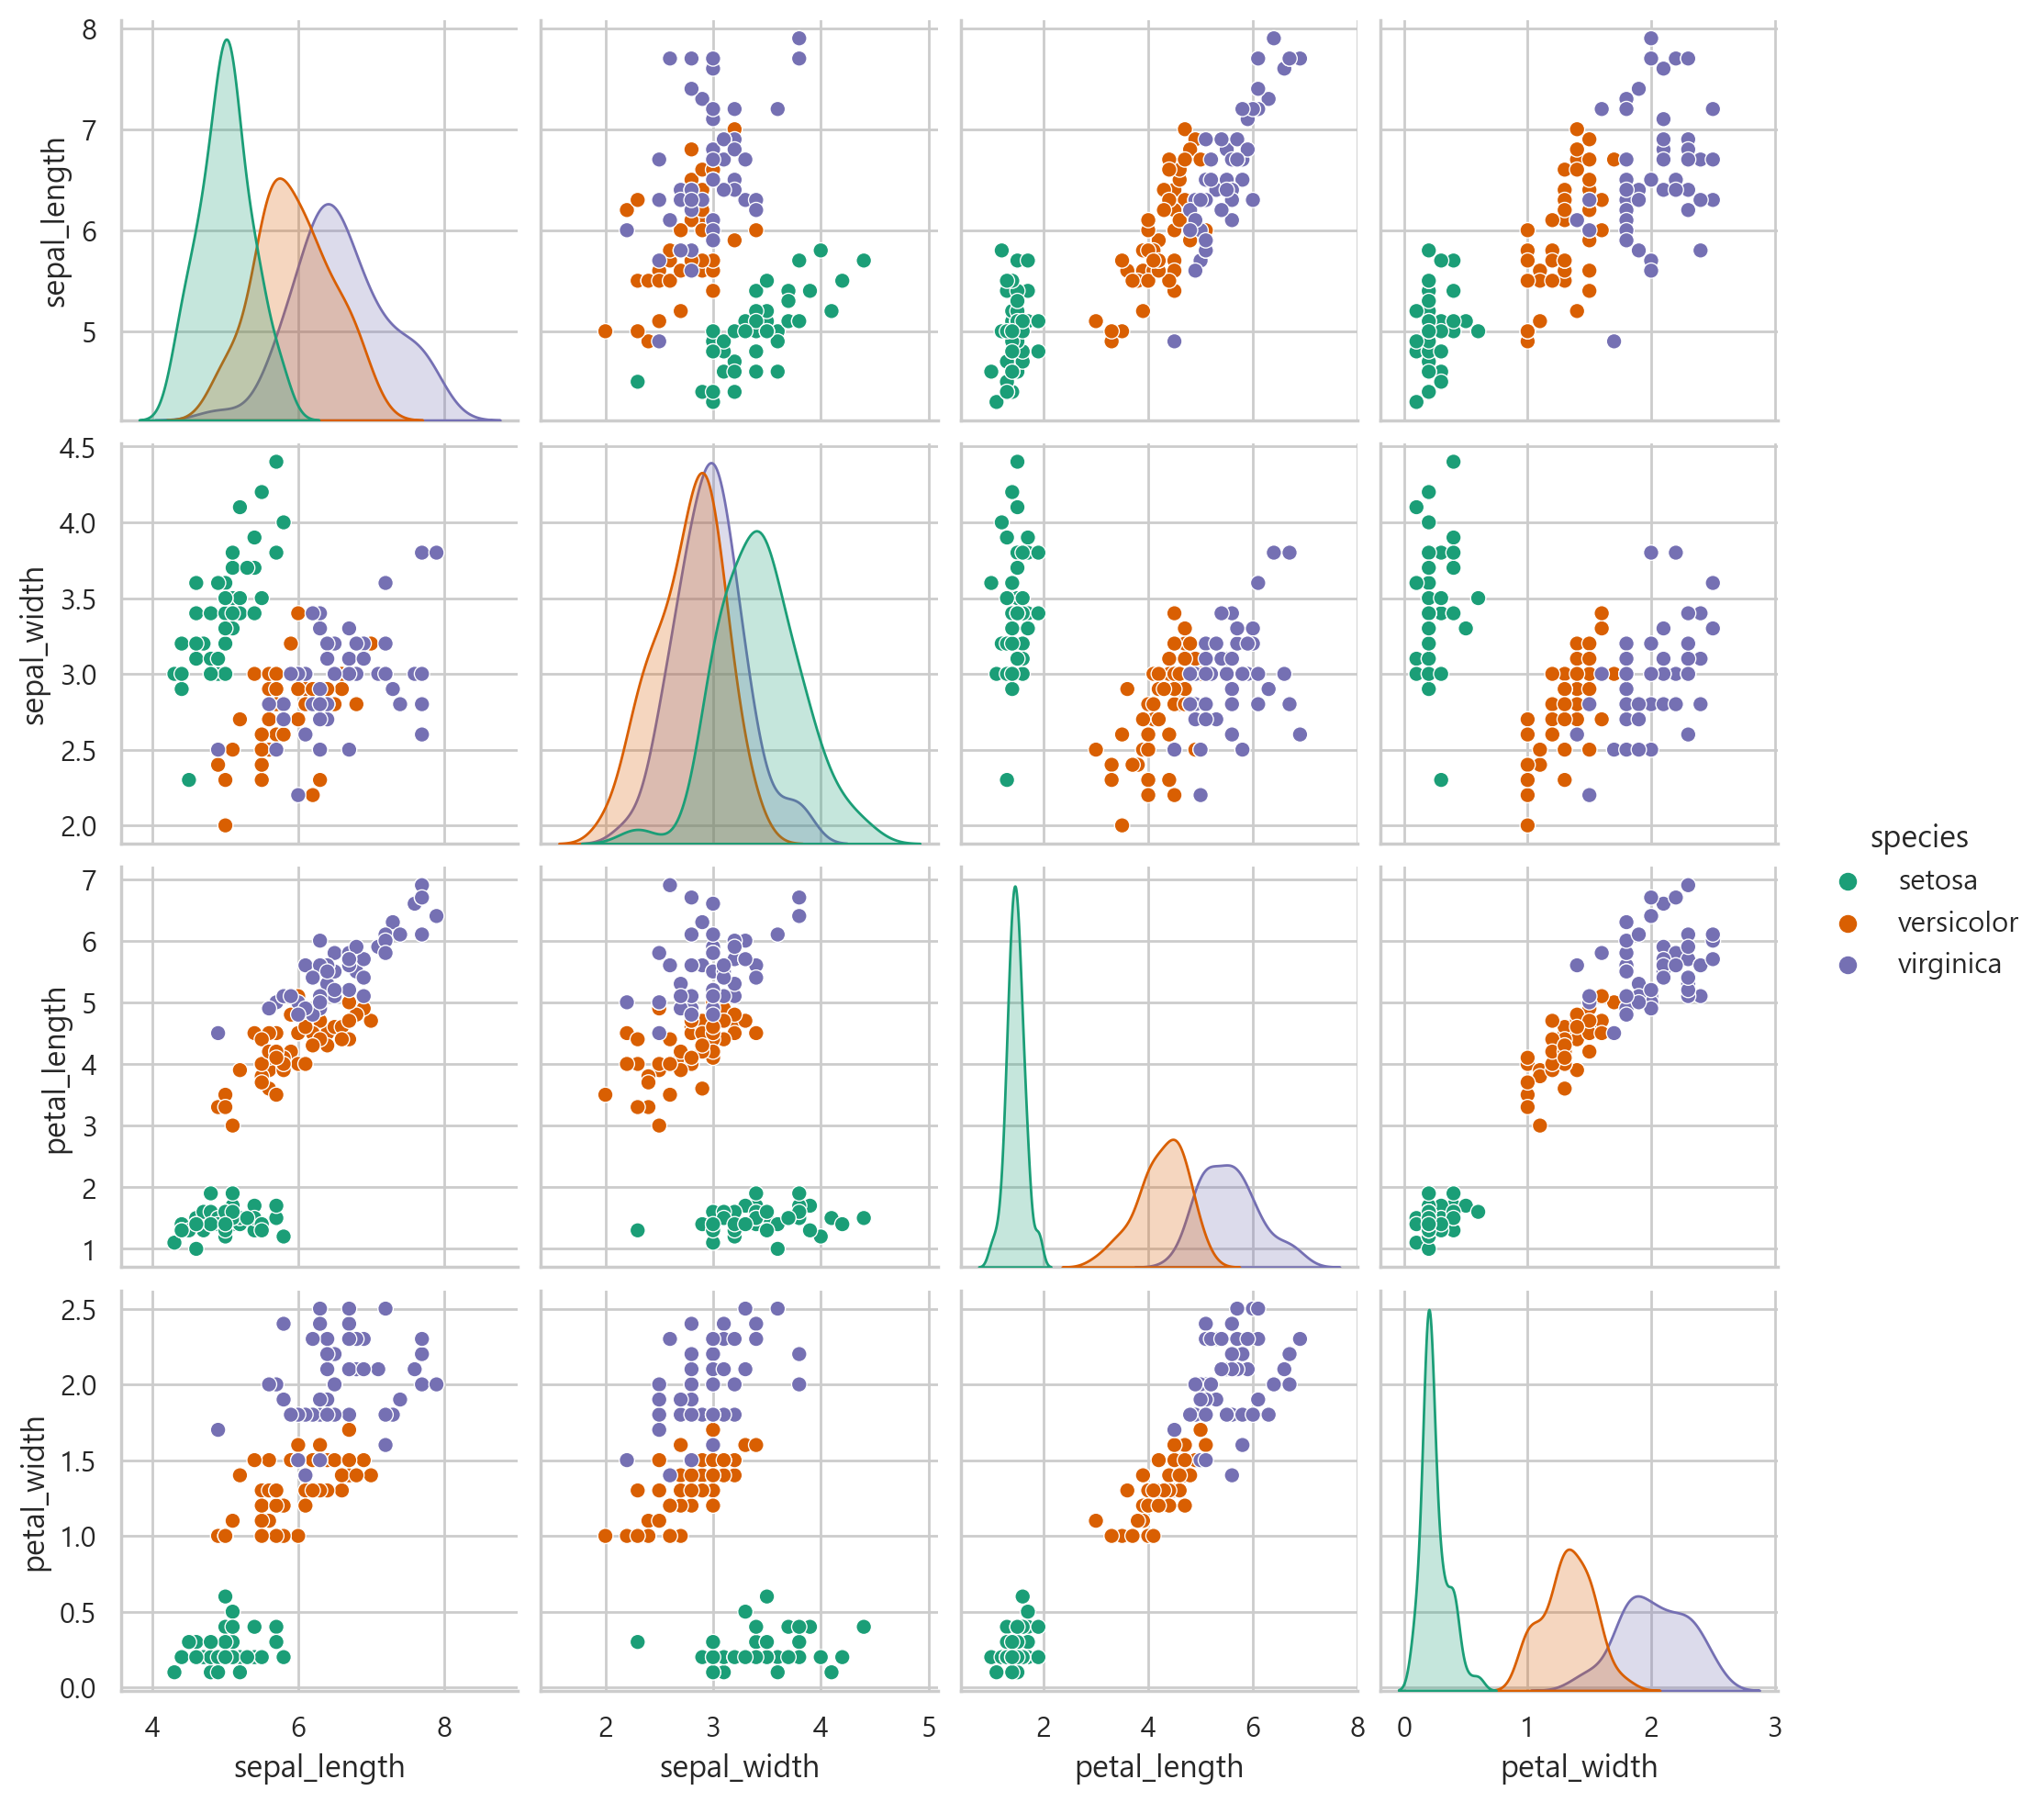

In [73]:
sns.pairplot(data=iris, hue='species')
plt.show()

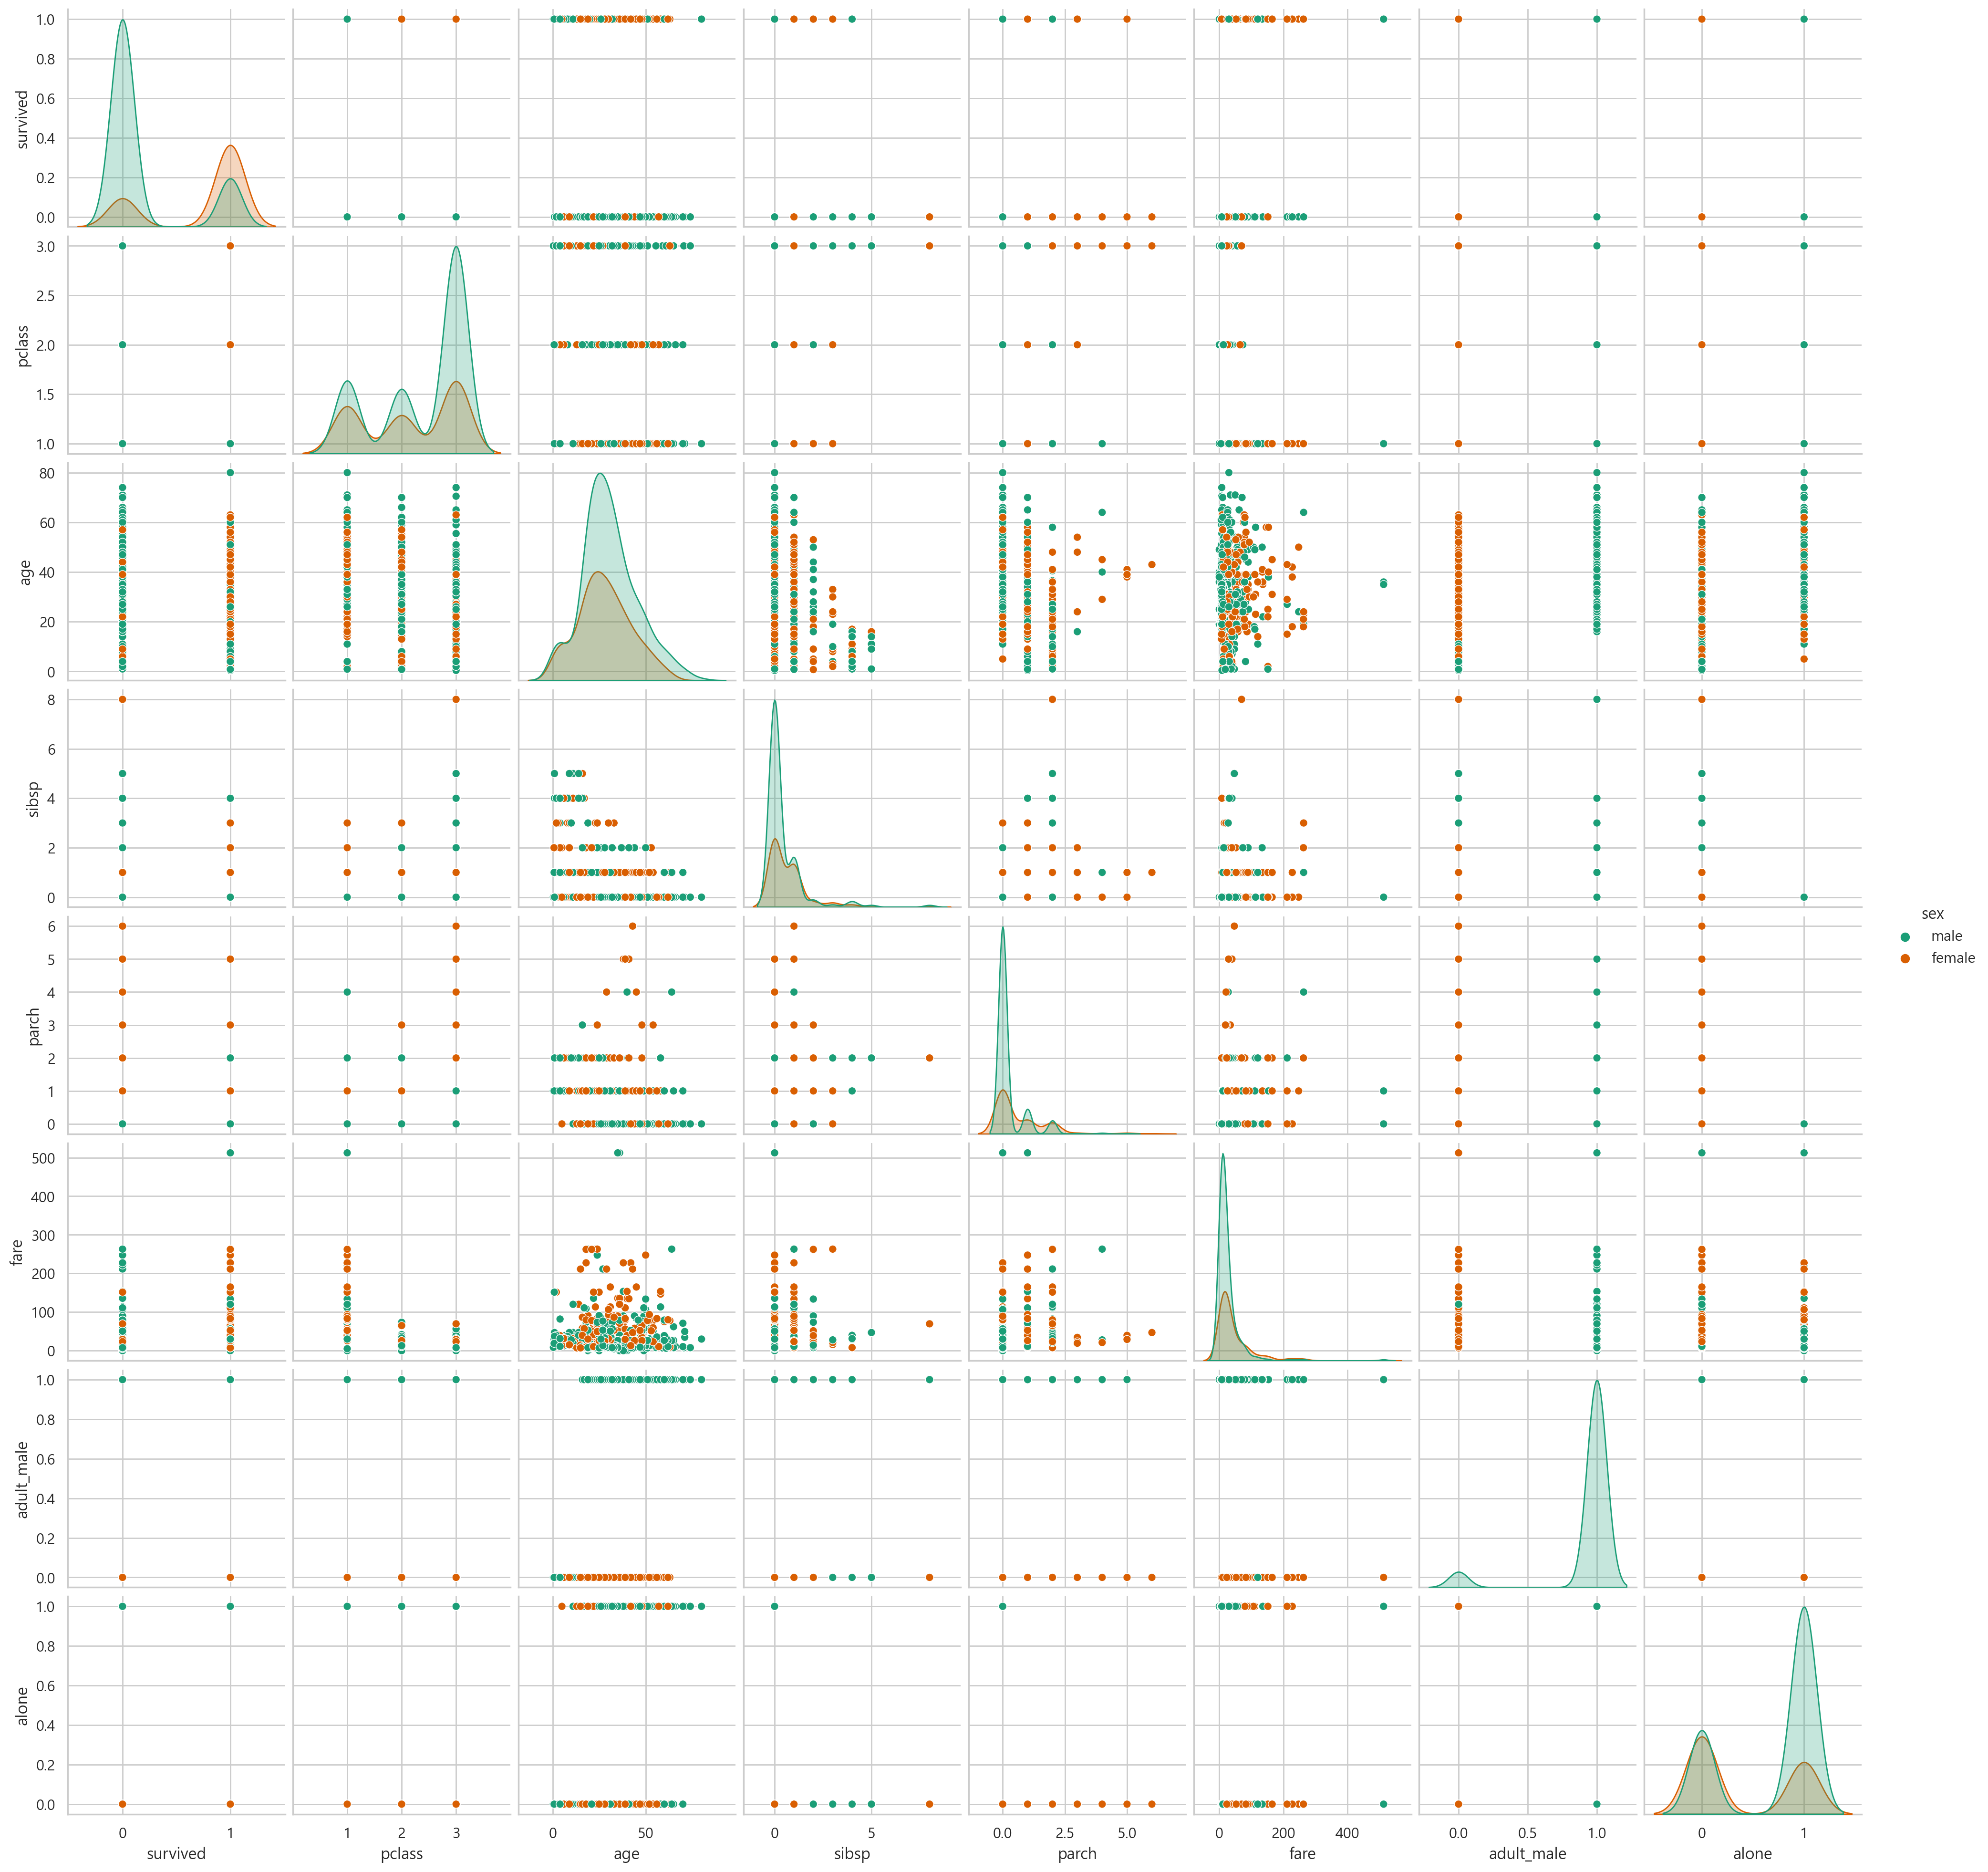

In [75]:
sns.pairplot(data=titanic, hue='sex')
plt.show()

### 4) 밀도 그래프

In [87]:
import numpy as np
x = np.random.randn(10000) # 평균0, 표준편차1인 정규분포로 10000개 1차원 배열

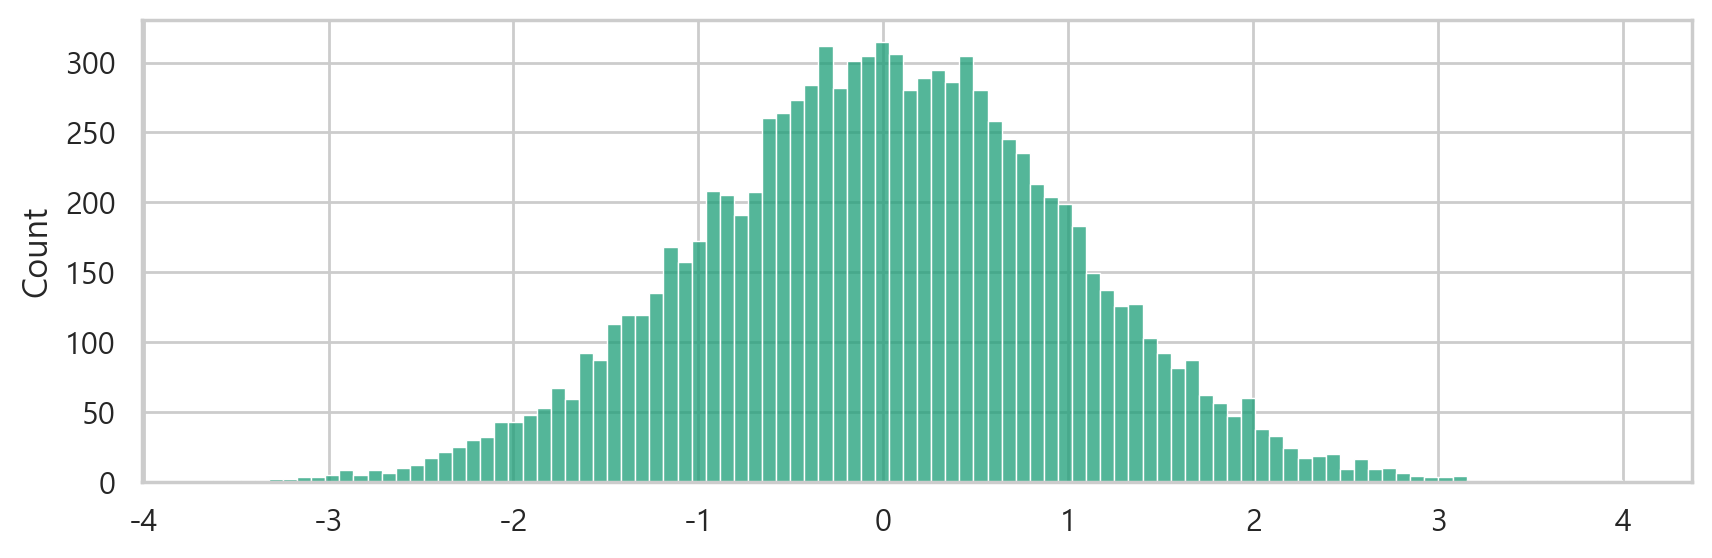

In [89]:
sns.histplot(x, bins=100)
plt.show()

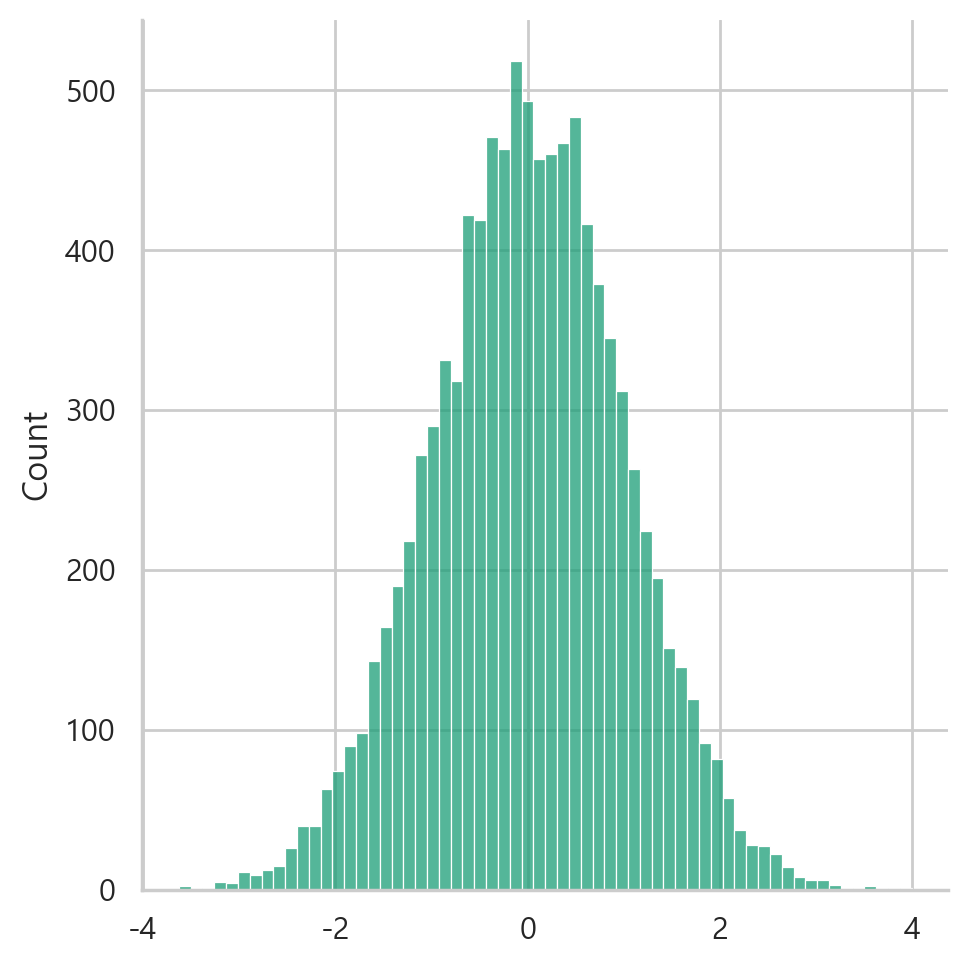

In [91]:
sns.displot(x)
plt.show()

In [92]:
### 5) 회귀 그래프
corr = iris.corr(numeric_only=True)
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


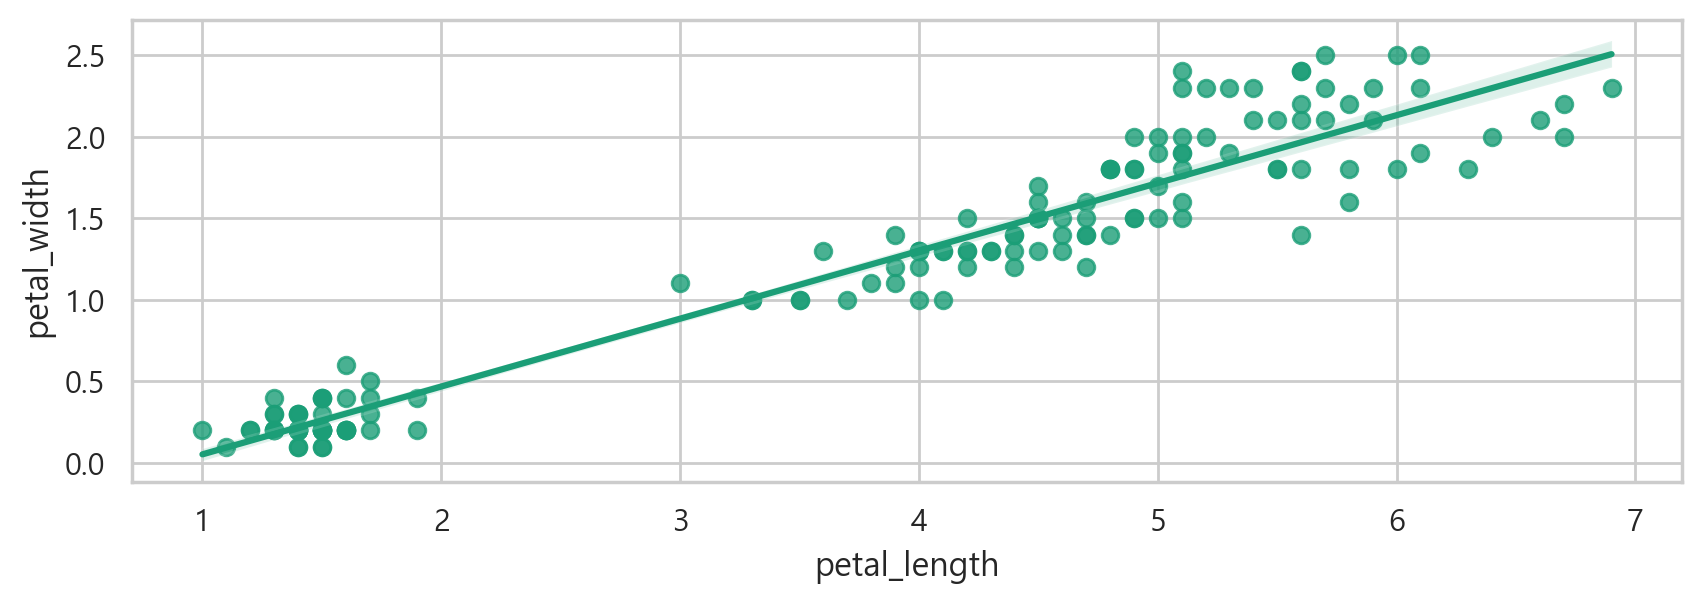

In [93]:
# 회귀 그래프 : regplot(hue 사용 불가), lmplot(hue 사용 가능)
sns.regplot(data=iris, x='petal_length', y='petal_width')
plt.show()

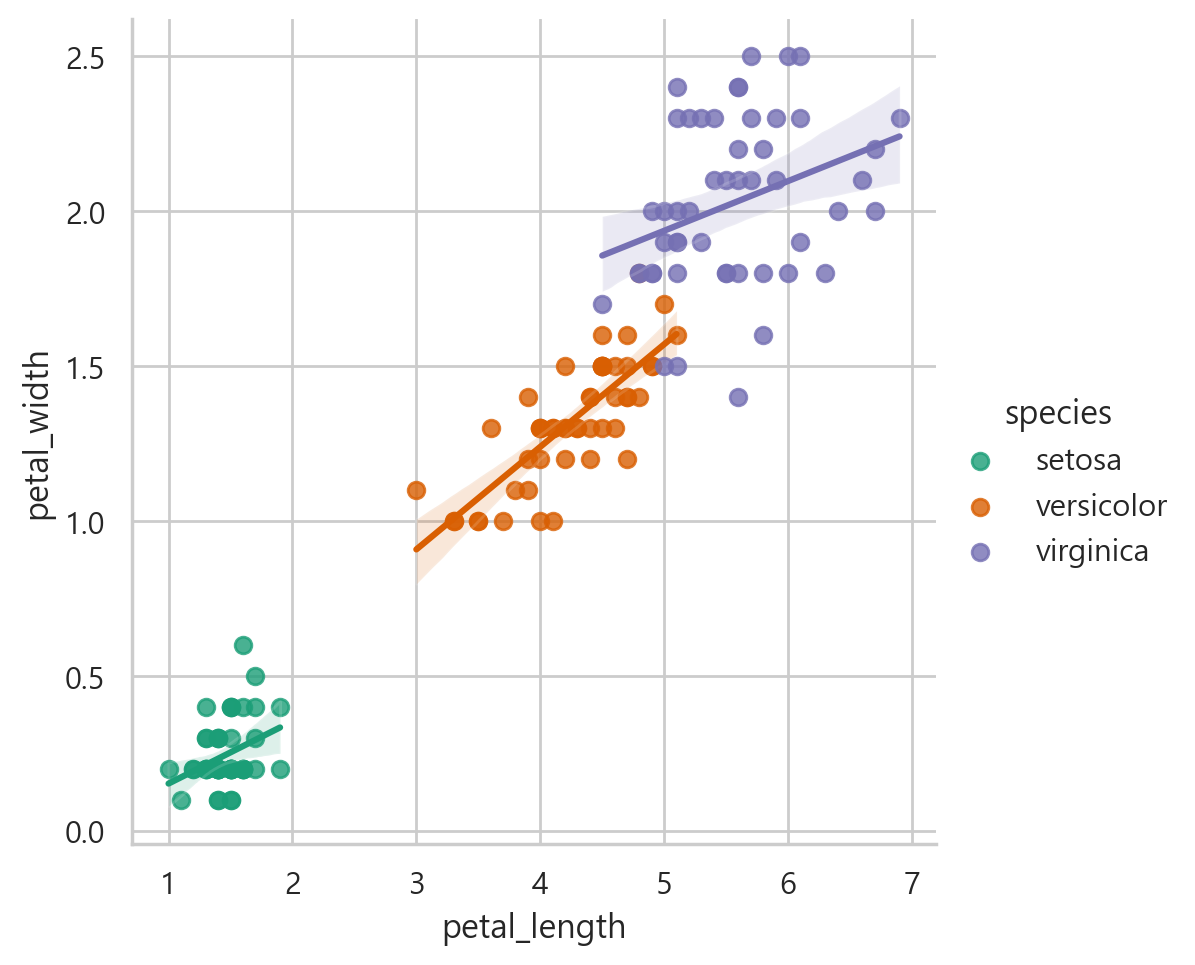

In [94]:
# 종별 회귀그래프
sns.lmplot(data=iris, x='petal_length', y='petal_width', 
           hue='species',
           #col='species',
          )
plt.show()

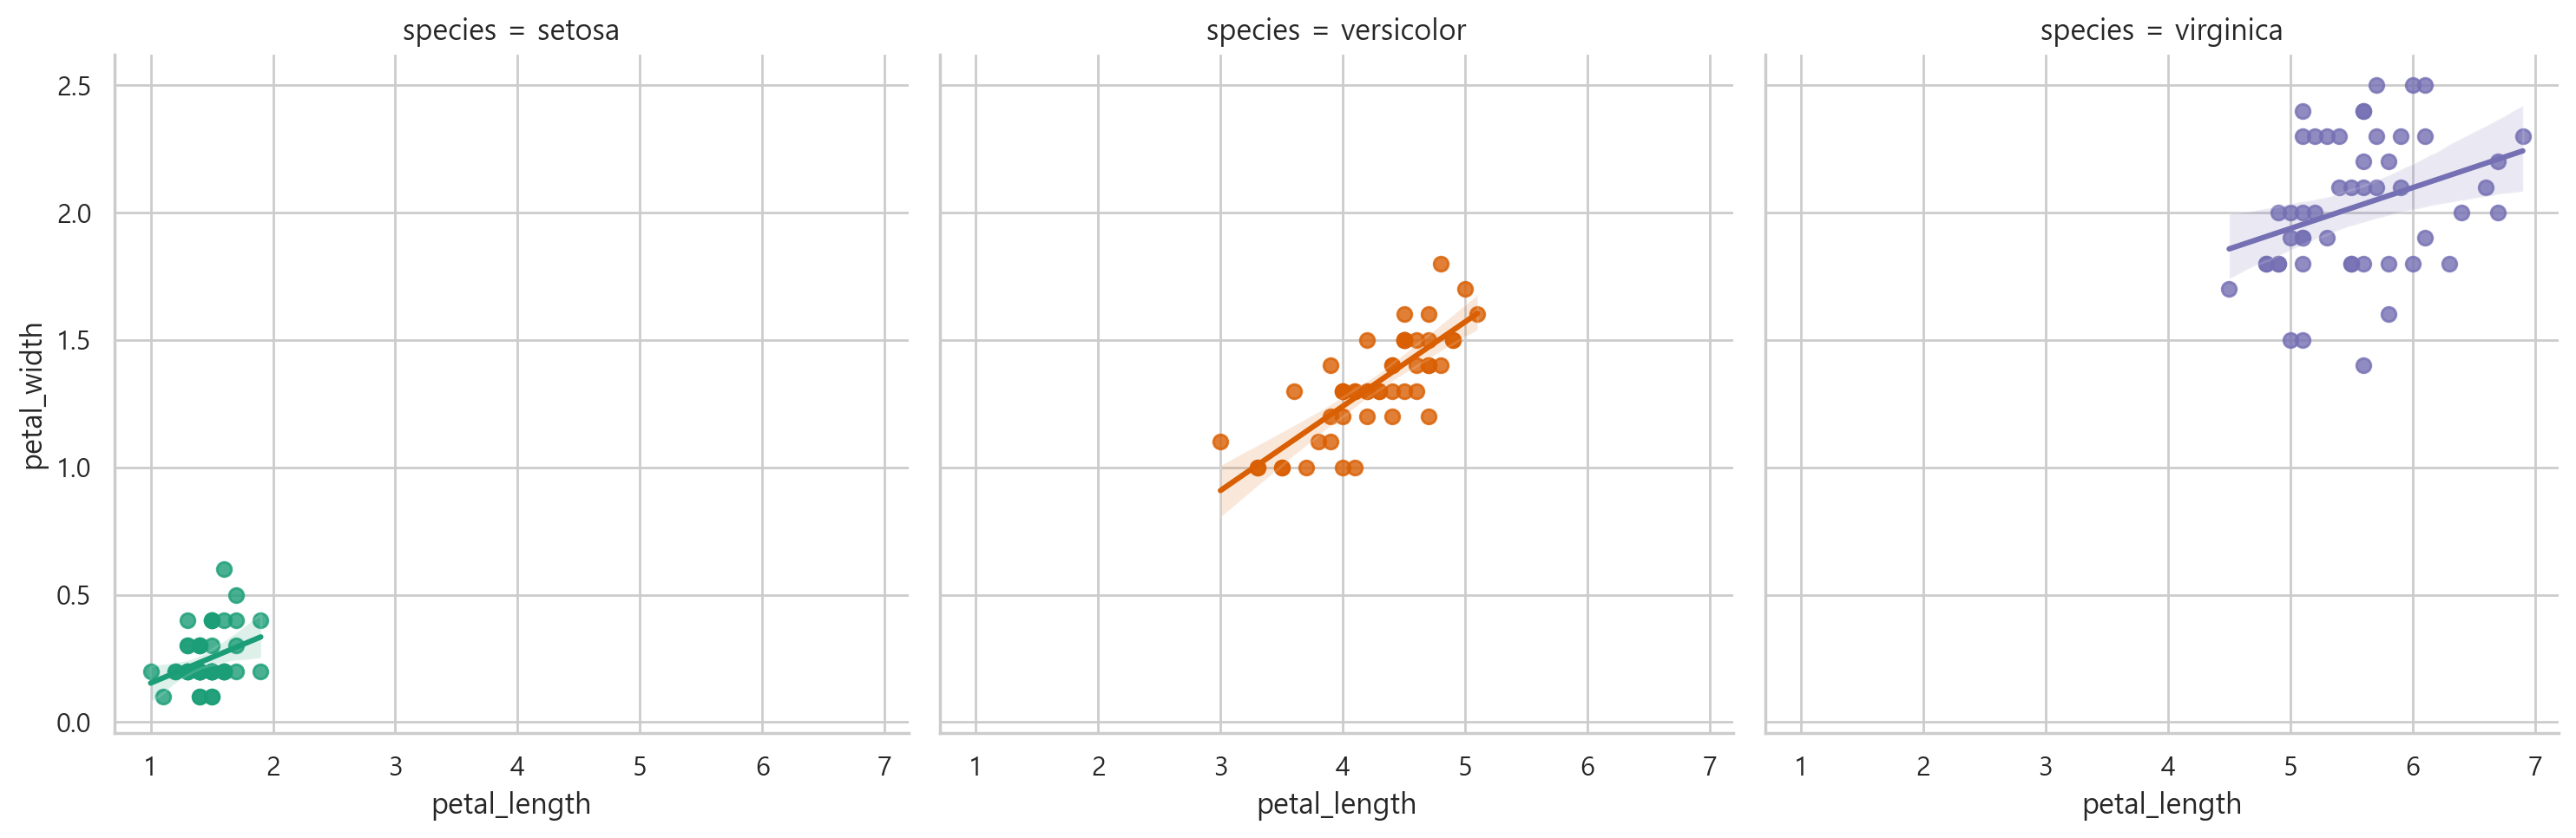

In [95]:
# 종별 회귀그래프
sns.lmplot(data=iris, x='petal_length', y='petal_width', 
           hue='species',
           col='species',
          )
plt.show()

## 2.4 다중그래프를 위한 Facetgrid
- https://seaborn.pydata.org/tutorial/axis_grids.html#conditional-small-multiples (교안 84page)

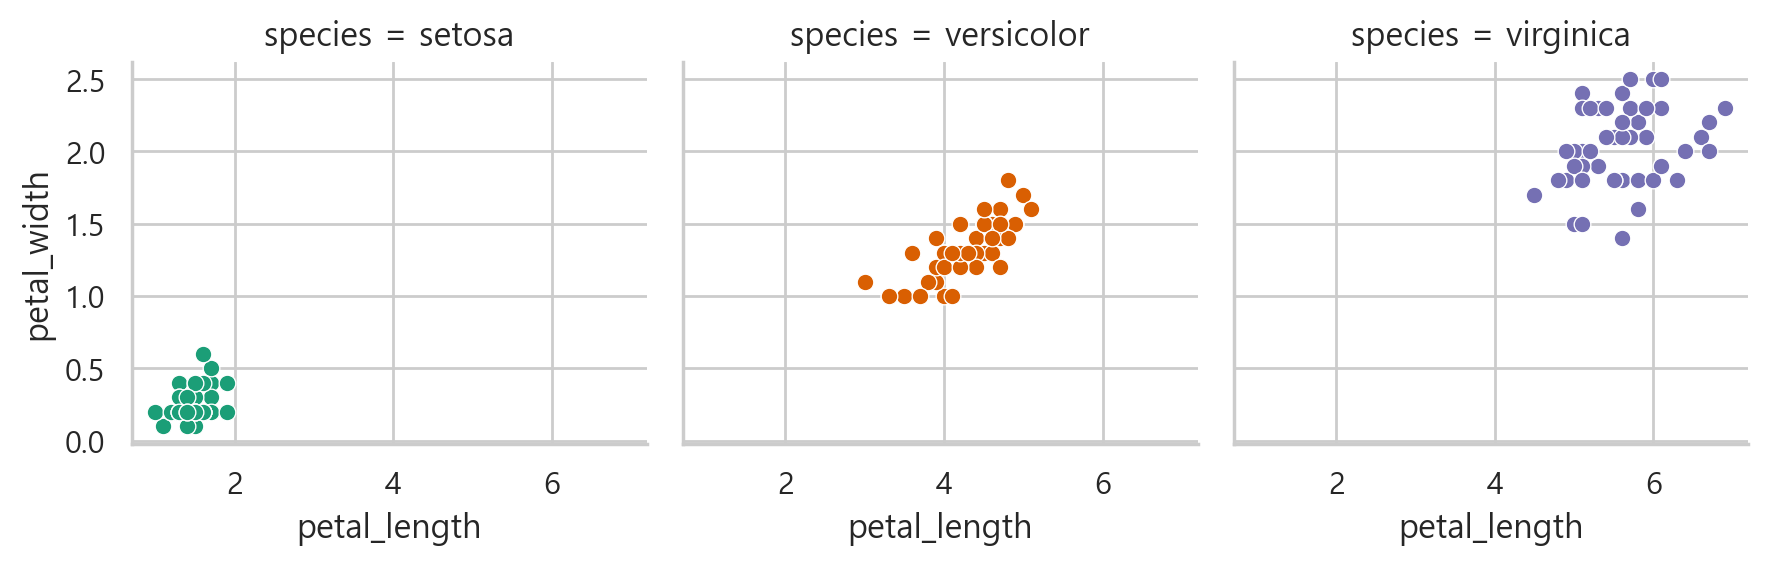

In [96]:
g = sns.FacetGrid(iris, col='species', hue='species')
g.map(sns.scatterplot, 'petal_length', 'petal_width')
plt.show()

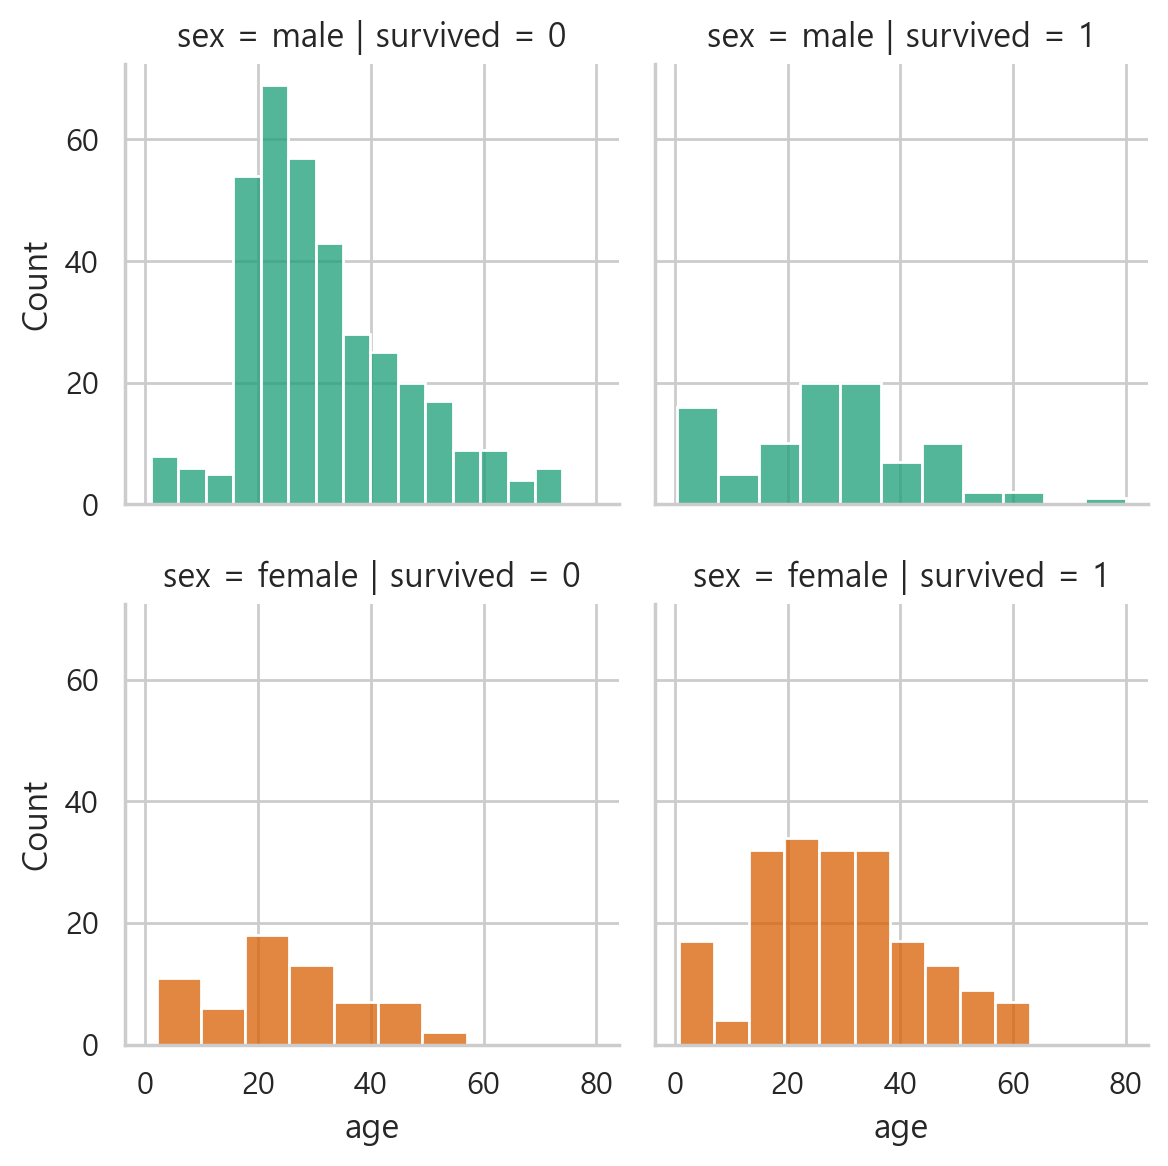

In [98]:
g = sns.FacetGrid(titanic, col='survived', hue='sex', row='sex')
g.map(sns.histplot, 'age')
plt.show()